# 1. Introduction
## ADHD Prediction using Socio-demographic and Brain Connectome Data

**Project Overview:**
This Project relates to Data Exploration as the first step. I will have a notebook covering Data Exploration.

In my project, I have four datasets:
- **Functional connectome matrices** consist of brain data of very high dimensions.
- The **Metadata A** refers to a number variable (e.g., age, score).
- the **Metadata B** refers to a categorical variable related to parental education, and SDQ
- The **labels** refer to an ADHD diagnosis and biological sex.

**Project Goals:**
- Predicting ADHD diagnosis and biological sex using this data. 
- I don’t misdiagnose people, considering the fairness of the models.
- My aim is to create an interpretable model using explanation methods such as SHAP or LIME.
- I prepare data for modeling by making it tidy and organized (Stage 2).

**In My notebook:**
- I will load all the datasets, and then I would like to visually and statistically explore each.
- I will check for any missing values or strange distributions in the datasets.
- I will figure out the method to preprocess the data. 
- I will consider how I want to build the model as well as how I will evaluate it.

No modeling will be performed in this part of my work. I want to get a sense of the data and prepare it for strong and fair machine learning. 

# 2. Load Data
The project uses four source datasets for exploration and preprocessing.
- The target labels such as **ADHD** and **sex** are contained in **LABELS.xlsx**.
- **METADATA_A.xlsx** contains numerical metadata.
- **METADATA_B.xlsx** contains categorical metadata.
- **FUNCTIONAL_CONNECTOME_MATRICES.csv** contains (fMRI data).

In [1]:
import os
import pandas as pd
import numpy as np 

# I write a relative path to the data folder
data_dir = "../data"

# This code shows paths for each file
path_labels = os.path.join(data_dir, "LABELS.xlsx")
path_meta_a = os.path.join(data_dir, "METADATA_A.xlsx")
path_meta_b = os.path.join(data_dir, "METADATA_B.xlsx")
path_connectome = os.path.join(data_dir, "FUNCTIONAL_CONNECTOME_MATRICES.csv")

# I loaded four file datasets
labels_df = pd.read_excel(path_labels)
metadata_a_df = pd.read_excel(path_meta_a)
metadata_b_df = pd.read_excel(path_meta_b)
connectome_df = pd.read_csv(path_connectome)

print("LABELS shape:", labels_df.shape)
print("Metadata A shape:", metadata_a_df.shape)
print("Metadata B shape:", metadata_b_df.shape)
print("Connectome shape:", connectome_df.shape)


LABELS shape: (1213, 3)
Metadata A shape: (1213, 19)
Metadata B shape: (1213, 10)
Connectome shape: (1213, 19901)


# 3. Explore Metadata A
I will carry out a thorough analysis of the **Metadata A** dataset that has socio-demographic and psychological variables in numbers. The aim of this step is to get to know the data before cleaning and bidding it for any further analysis.

**My exploration steps:**
- I revealed the overall features of the dataset (columns, types).
- I made an attempt to create a stats summary of each number feature.
- I will show the first few rows to understand sample values in the dataset.
- I check the skewness of numeric columns to see if there is any problem with data distribution.
- I will look at the distribution of each feature using histograms.
- I make boxplots that indicate possible outliers.




DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   participant_id              1213 non-null   object 
 1   EHQ_EHQ_Total               1213 non-null   float64
 2   ColorVision_CV_Score        1213 non-null   int64  
 3   APQ_P_APQ_P_CP              1213 non-null   int64  
 4   APQ_P_APQ_P_ID              1213 non-null   int64  
 5   APQ_P_APQ_P_INV             1213 non-null   int64  
 6   APQ_P_APQ_P_OPD             1213 non-null   int64  
 7   APQ_P_APQ_P_PM              1213 non-null   int64  
 8   APQ_P_APQ_P_PP              1213 non-null   int64  
 9   SDQ_SDQ_Conduct_Problems    1213 non-null   int64  
 10  SDQ_SDQ_Difficulties_Total  1213 non-null   int64  
 11  SDQ_SDQ_Emotional_Problems  1213 non-null   int64  
 12  SDQ_SDQ_Externalizing       1213 non-null   int64  
 13  SDQ_SDQ_Generat

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
count,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,853.000000
mean,58.876917,13.164880,3.781533,13.205276,39.374279,17.785655,16.393240,25.246496,2.059357,12.122836,2.307502,7.557296,4.073372,5.497939,4.565540,2.258038,7.683430,11.245678
std,49.855501,2.780624,1.376700,3.811772,6.245928,3.764112,5.376994,3.950529,2.023322,6.577207,2.167549,4.166627,2.819731,2.836764,3.519634,2.090414,2.190295,3.234372
min,-100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,45.600000,14.000000,3.000000,11.000000,36.000000,16.000000,13.000000,23.000000,0.000000,7.000000,1.000000,4.000000,2.000000,4.000000,2.000000,0.000000,6.000000,8.803901
50%,76.670000,14.000000,3.000000,13.000000,40.000000,18.000000,16.000000,26.000000,2.000000,12.000000,2.000000,7.000000,4.000000,6.000000,4.000000,2.000000,8.000000,10.739219
75%,93.400000,14.000000,4.000000,16.000000,43.000000,20.000000,19.000000,28.000000,3.000000,17.000000,4.000000,10.000000,6.000000,8.000000,7.000000,4.000000,10.000000,13.460871
max,100.000000,14.000000,12.000000,28.000000,50.000000,28.000000,37.000000,30.000000,10.000000,34.000000,10.000000,20.000000,10.000000,10.000000,17.000000,9.000000,10.000000,21.564453




First 5 Rows:


,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,UmrK0vMLopoR,40.00,13,3,10,47,13,11,28,0,6,1,5,0,5,1,0,10,NaN
1,CPaeQkhcjg7d,-94.47,14,3,13,34,18,23,30,0,18,6,8,7,8,10,4,5,NaN
2,Nb4EetVPm3gs,-46.67,14,4,10,35,16,10,29,1,14,2,8,5,7,6,4,9,8.239904
3,p4vPhVu91o4b,-26.68,10,5,12,39,19,16,28,6,24,4,16,9,10,8,4,6,NaN
4,M09PXs7arQ5E,0.00,14,5,15,40,20,24,28,1,18,4,11,4,10,7,3,9,8.940679




Missing Values Per Column:
participant_id                  0
EHQ_EHQ_Total                   0
ColorVision_CV_Score            0
APQ_P_APQ_P_CP                  0
APQ_P_APQ_P_ID                  0
APQ_P_APQ_P_INV                 0
APQ_P_APQ_P_OPD                 0
APQ_P_APQ_P_PM                  0
APQ_P_APQ_P_PP                  0
SDQ_SDQ_Conduct_Problems        0
SDQ_SDQ_Difficulties_Total      0
SDQ_SDQ_Emotional_Problems      0
SDQ_SDQ_Externalizing           0
SDQ_SDQ_Generating_Impact       0
SDQ_SDQ_Hyperactivity           0
SDQ_SDQ_Internalizing           0
SDQ_SDQ_Peer_Problems           0
SDQ_SDQ_Prosocial               0
MRI_Track_Age_at_Scan         360
dtype: int64


Skewness of Numeric Columns:
EHQ_EHQ_Total                -1.622435
ColorVision_CV_Score         -4.006743
APQ_P_APQ_P_CP                1.571377
APQ_P_APQ_P_ID               -0.189873
APQ_P_APQ_P_INV              -2.484126
APQ_P_APQ_P_OPD              -0.906061
APQ_P_APQ_P_PM                0.588060
APQ_P_AP

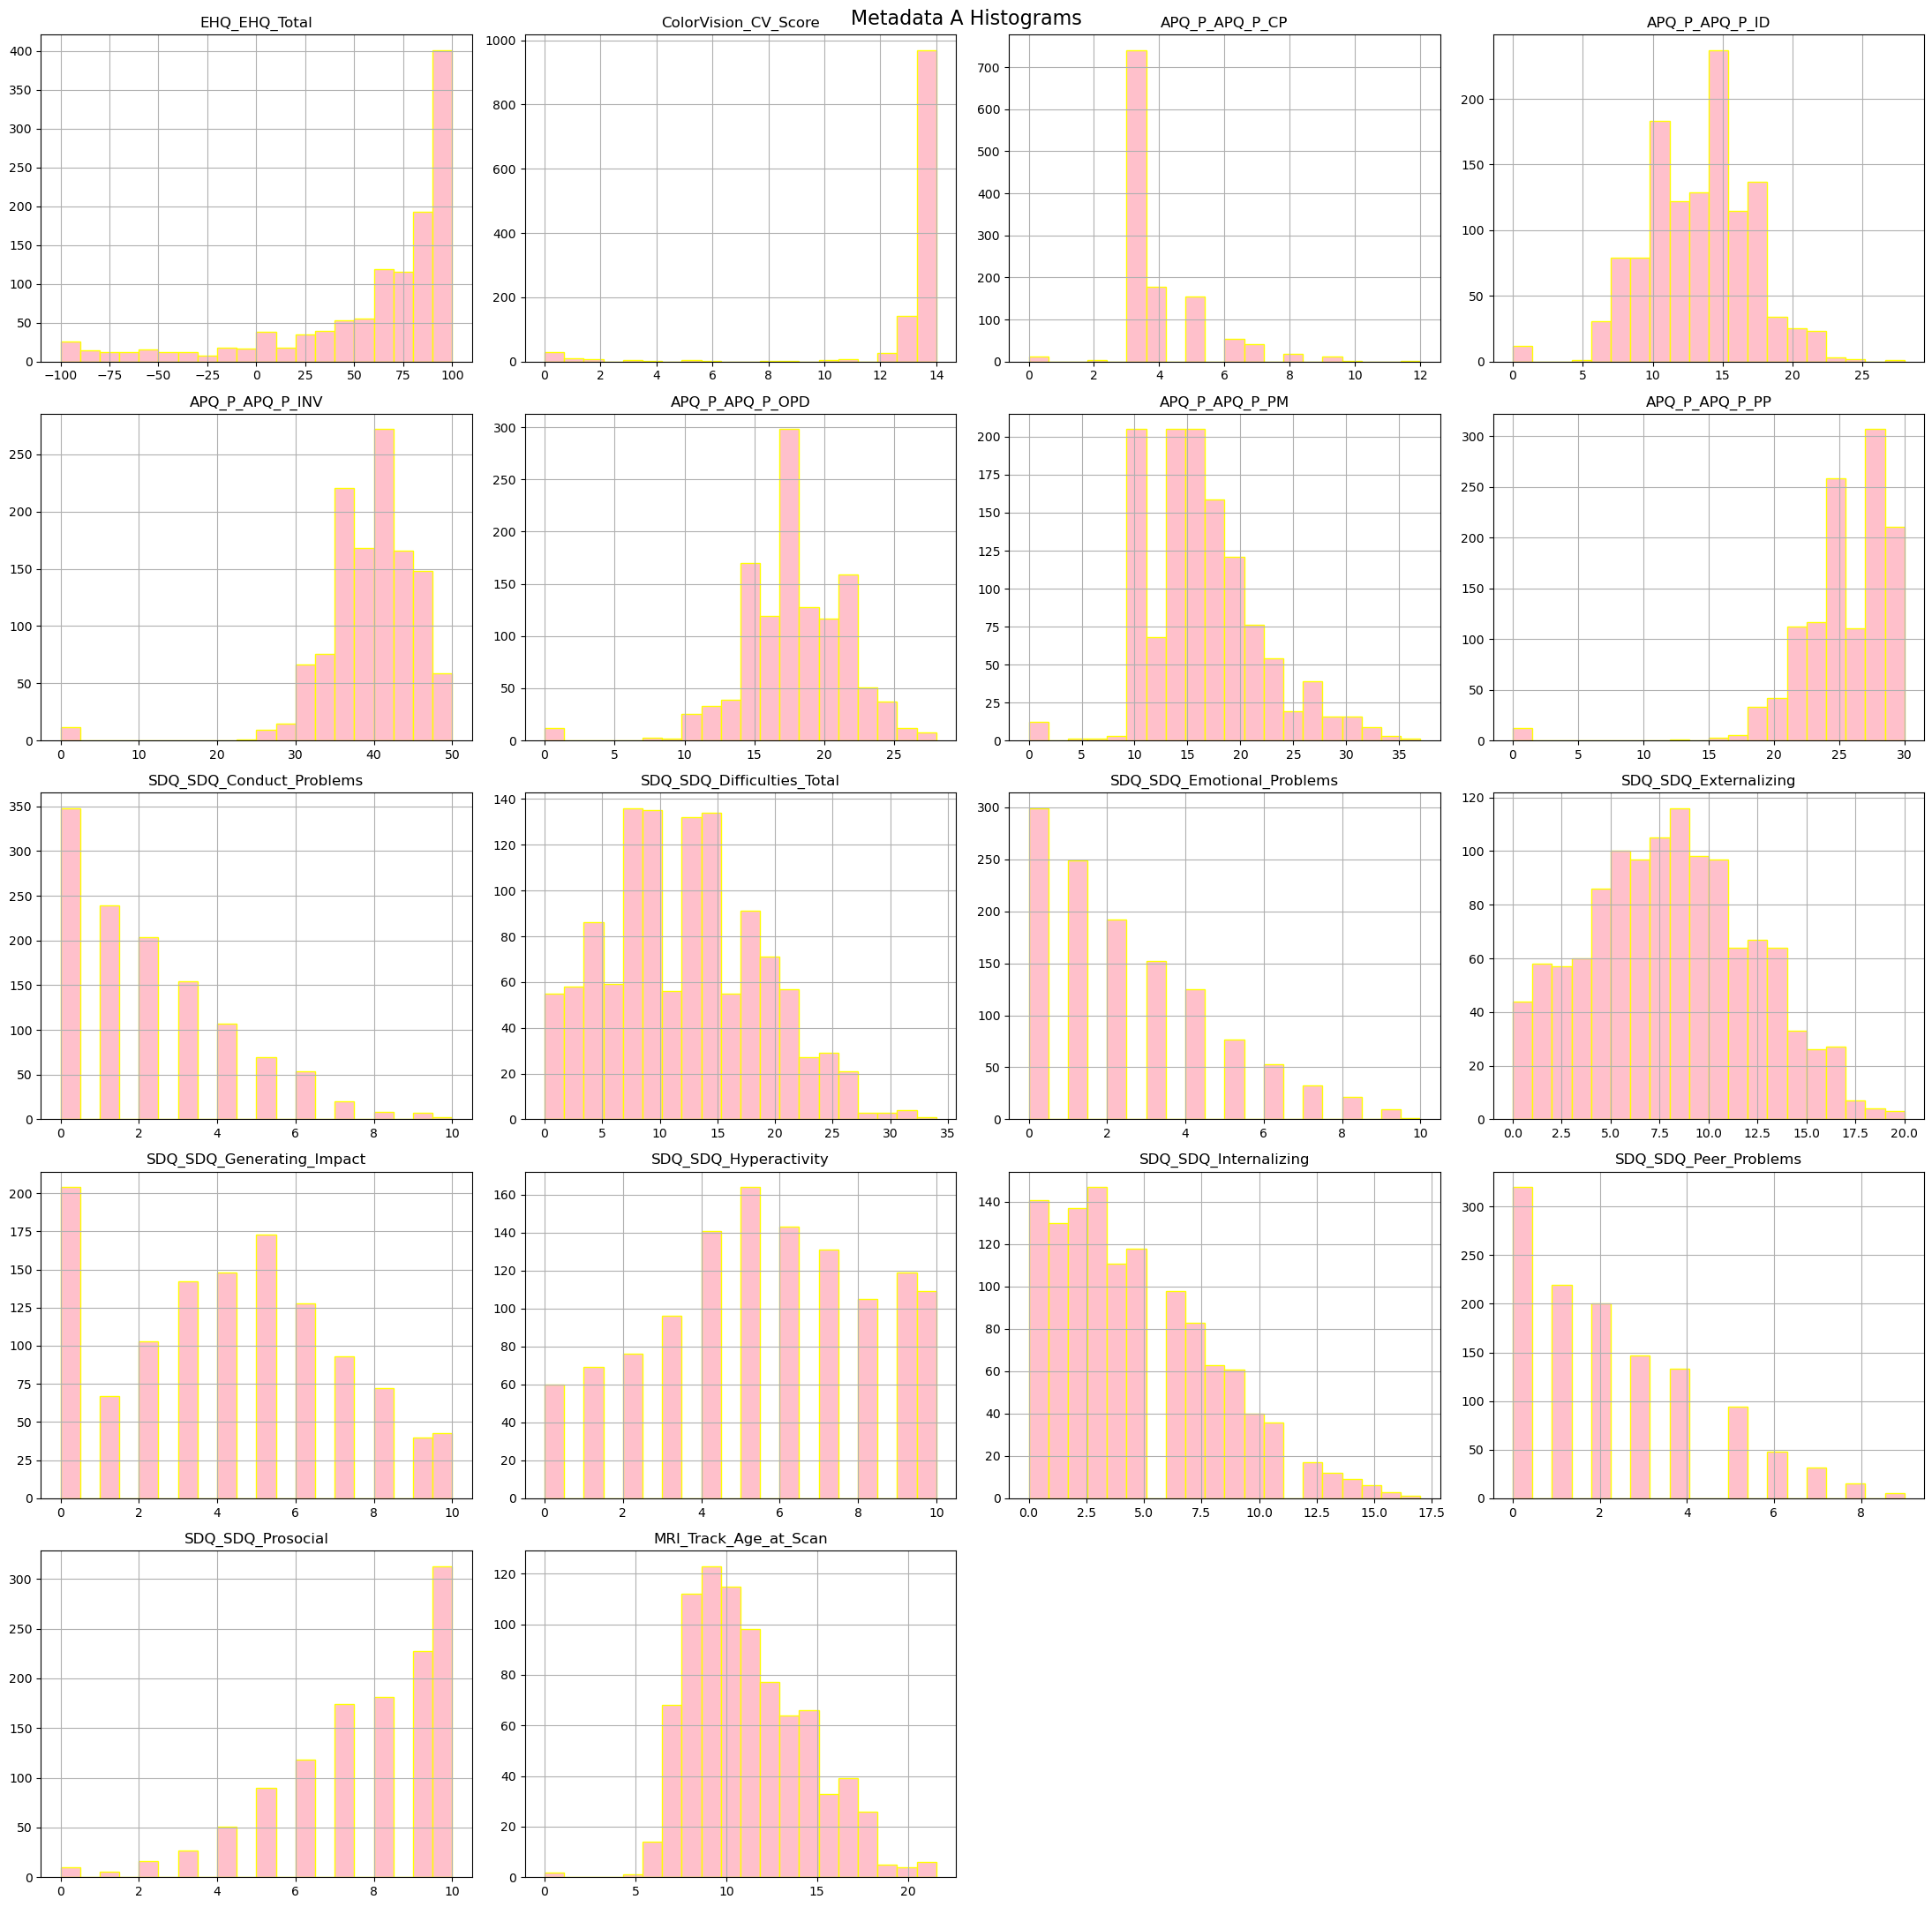

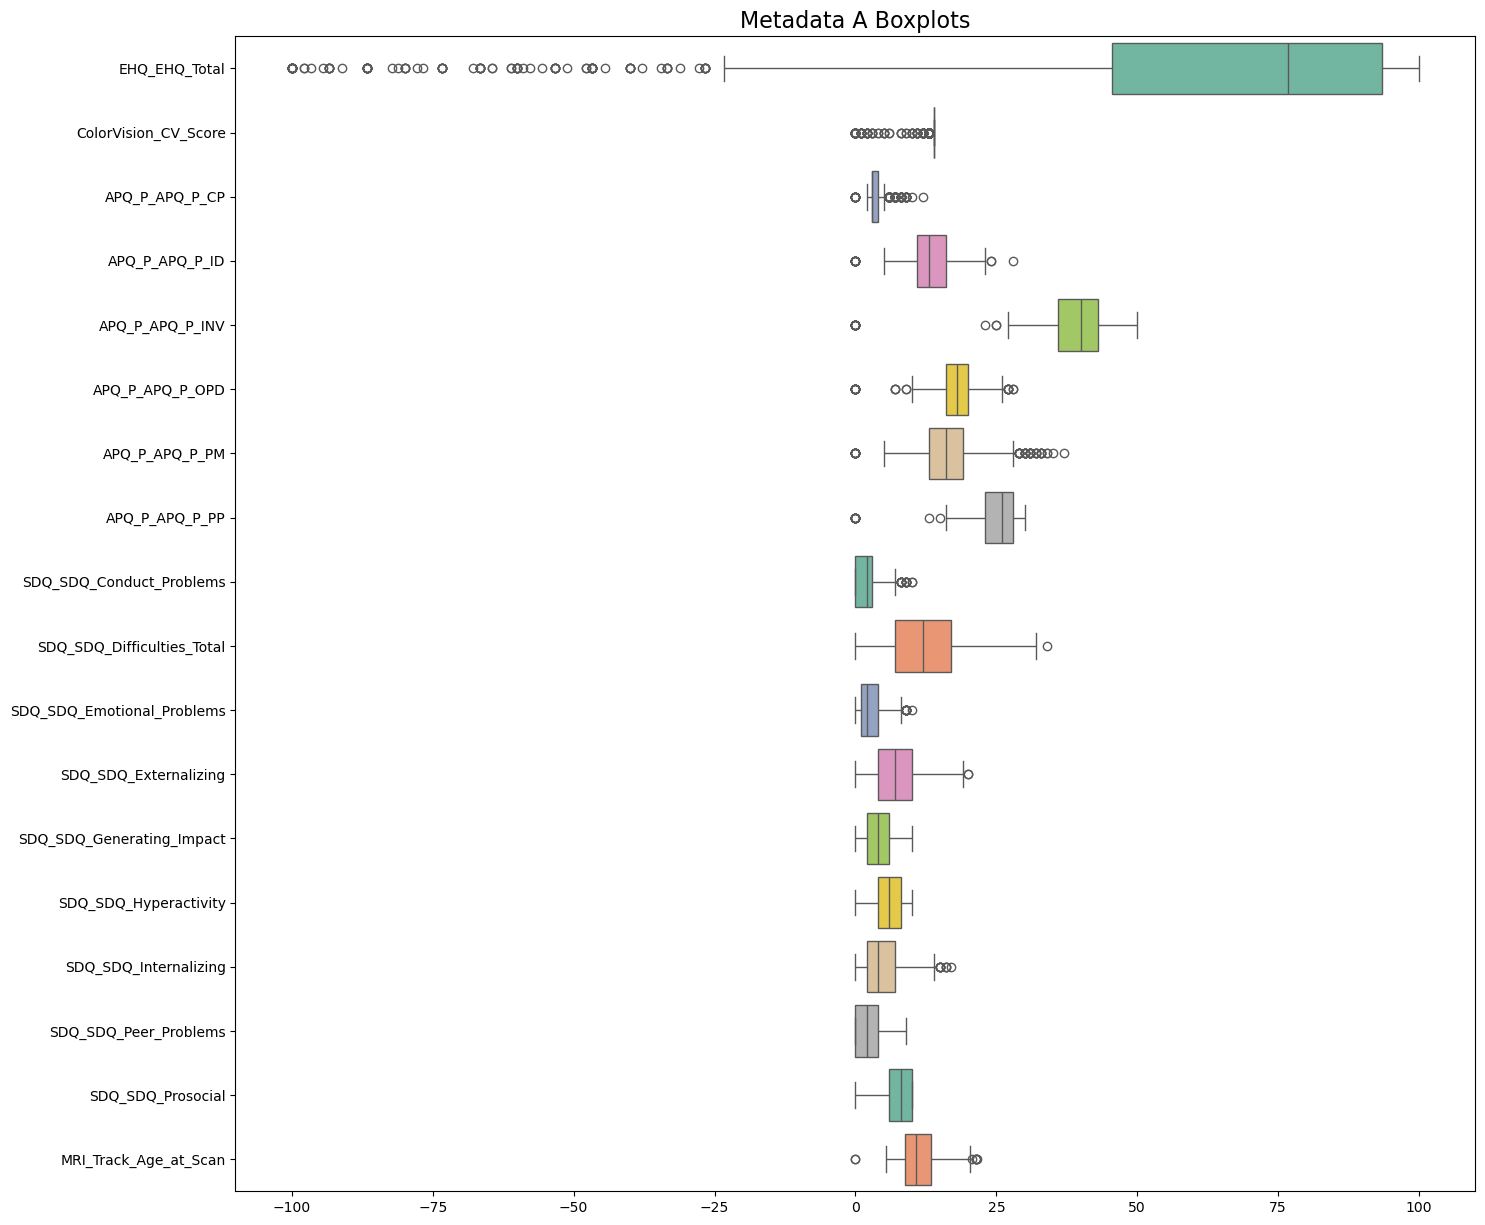

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# My data pathway
data_dir = "../data"
path_meta_a = os.path.join(data_dir, "METADATA_A.xlsx")

# Here I how the Metadata A
metadata_a_df = pd.read_excel(path_meta_a)

# I use a function to explore numeric data frames
def explore_numeric_dataframe(df, title_prefix=""):
    print("\n")
    print("DataFrame Info:")
    df.info()
    print("\n")

    print("Statistical Summary:")
    display(df.describe())
    print("\n")

    print("First 5 Rows:")
    display(df.head())
    print("\n")

    print("Missing Values Per Column:")
    print(df.isnull().sum())
    print("\n")

    print("Skewness of Numeric Columns:")
    print(df.skew(numeric_only=True))
    print("\n")

    # I use IQR method to identify outliers
    # print("Outlier Detection (IQR method):")
    # numeric_cols = df.select_dtypes(include=[np.number]).columns
    # for col in numeric_cols:
        # Q1 = df[col].quantile(0.25)
        # Q3 = df[col].quantile(0.75)
        # Interquartile Range
        # IQR = Q3 - Q1                                                                        
        # lower_bound = Q1 - 1.5 * IQR             
        # upper_bound = Q3 + 1.5 * IQR
        # outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        # outlier_count = outliers.shape[0]
        # print(f"{col}: {outlier_count} outliers")
    print("\n")

    # I create a Histograms chart
    df.hist(bins=20, figsize=(22, 22), color='pink', edgecolor='yellow')
    plt.suptitle(f"{title_prefix} Histograms", fontsize=16)
    plt.tight_layout()
    plt.show()

    # I create a Boxplots chart
    plt.figure(figsize=(16, 15))
    sns.boxplot(data=df, orient="h", palette="Set2")
    plt.title(f"{title_prefix} Boxplots", fontsize=16)
    print("\n")
    plt.show()
    

# This code is about calling my function on Metadata A
explore_numeric_dataframe(metadata_a_df, title_prefix="Metadata A")


# Analysis of Metadata A

As you can see from the output of my code, I did an initial exploration of the numerical socio-demographic features from Metadata A. 
**My observations include:**
- Missing Values: Only the column MRI_Track_Age_at_Scan has missing values with the number 360.

## Data spread:
- I can see that ColorVision_CV_Score with the number (-4.006), APQ_P_APQ_P_PP (-2.71), EHQ_EHQ_Total (-1.622) are all highly negatively skewed and non-normal which can affect the model’s performance.
- Some variables look unbalanced or skewed a little like Emotional_Problems and Hyperactivity.

## Skewness:
- Many variables like ColorVision_CV_Score show a strong skewness greater than 1.(absolute)

## Histogram Insights:
- My histograms show that many distributions are not normal.
- The ColorVision_CV_Score displays a strong skewness and has extreme values.
- EHQ_EHQ_Total shows extreme ranges and extreme outliers 

## Boxplot Observations:
- The boxplots visually confirm the presence of outliers for several variables:
- EHQ_EHQ_Total is very stretched and has extreme values.
- ColorVision_CV_Score and APQ_P_APQ_P_PM have many extreme values, too.
- SDQ_SDQ_Difficulties_Total includes large upper values.
- MRI_Track_Age_at_Scan looks at almost symmetric and balanced other-hand

# 4. Explore Metadata B
I explored the categorical demographic features in the Metadata B file. My goal is to understand the spread of values across different variables and find any unusual problems in the data.
- All columns are divided into two parts categorical or ordinal.
- I try to find missing values.
- I use **Countplots to visually explore the spread of values**.
- How can I fill in missing values in categorical columns?
- I try to group rare categories together to reduce noise.

DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    1213 non-null   object 
 1   Basic_Demos_Enroll_Year           1213 non-null   int64  
 2   Basic_Demos_Study_Site            1213 non-null   int64  
 3   PreInt_Demos_Fam_Child_Ethnicity  1202 non-null   float64
 4   PreInt_Demos_Fam_Child_Race       1213 non-null   int64  
 5   MRI_Track_Scan_Location           1213 non-null   int64  
 6   Barratt_Barratt_P1_Edu            1213 non-null   int64  
 7   Barratt_Barratt_P1_Occ            1213 non-null   int64  
 8   Barratt_Barratt_P2_Edu            1213 non-null   int64  
 9   Barratt_Barratt_P2_Occ            1213 non-null   int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 94.9+ KB


Value Counts for Column: Basic_Demos_Enroll_Year
Basic_

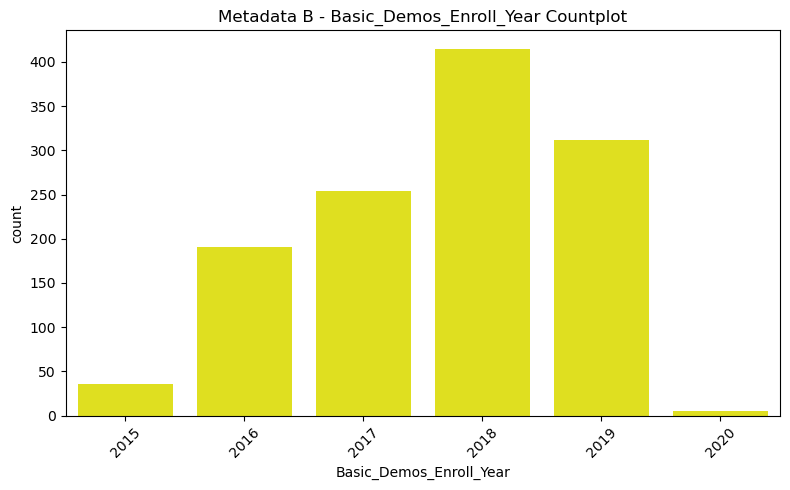

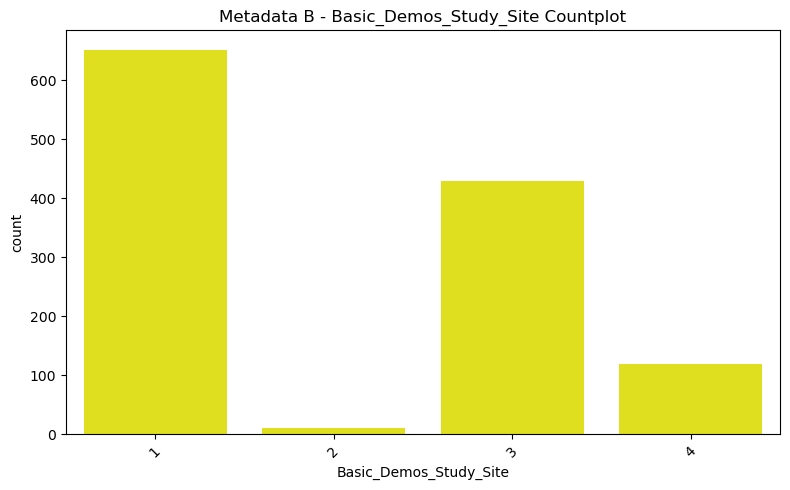

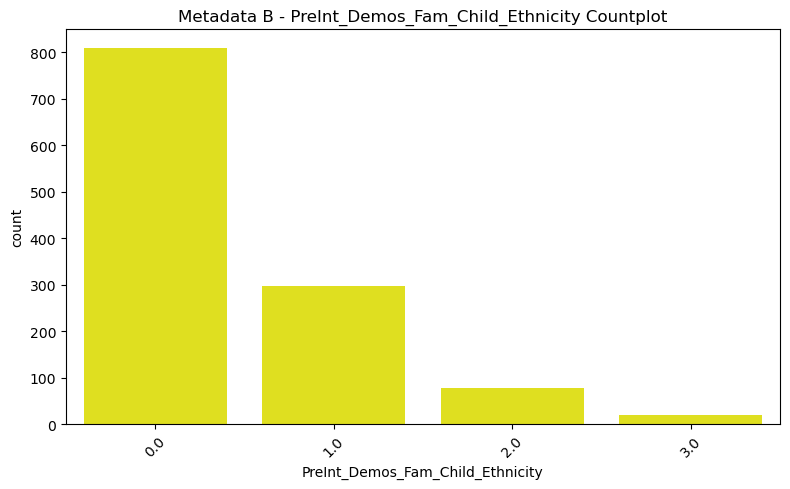

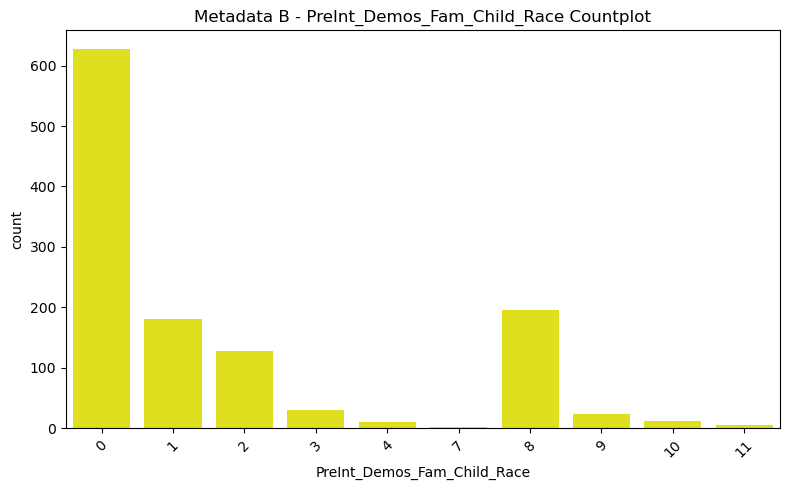

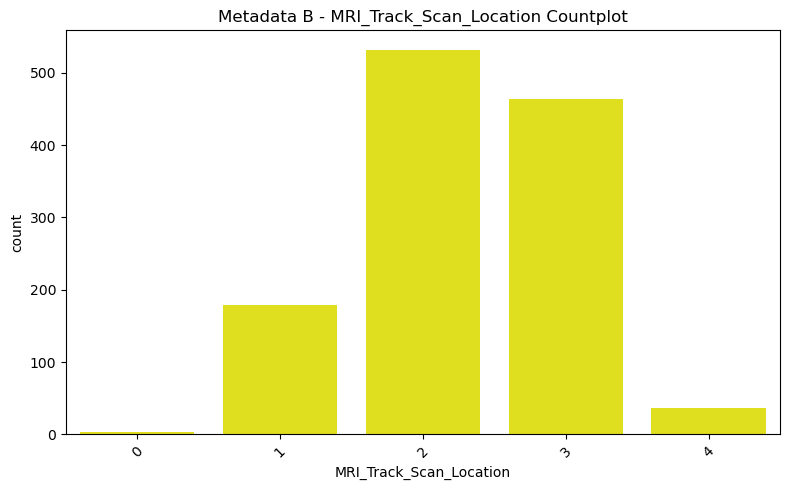

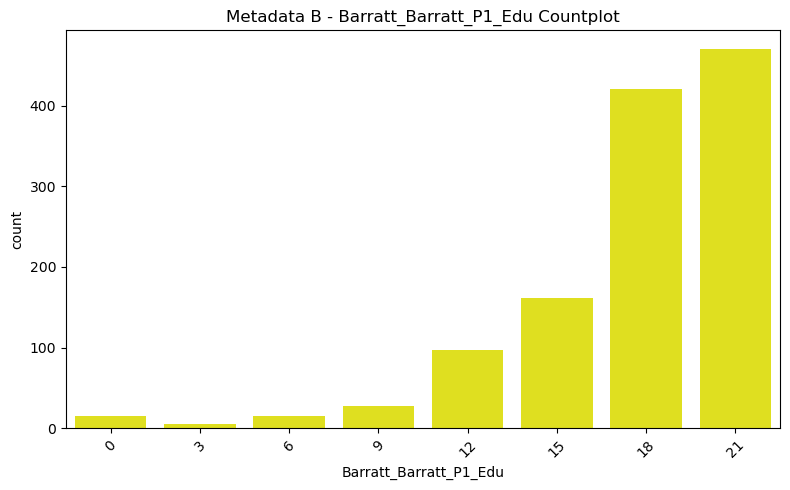

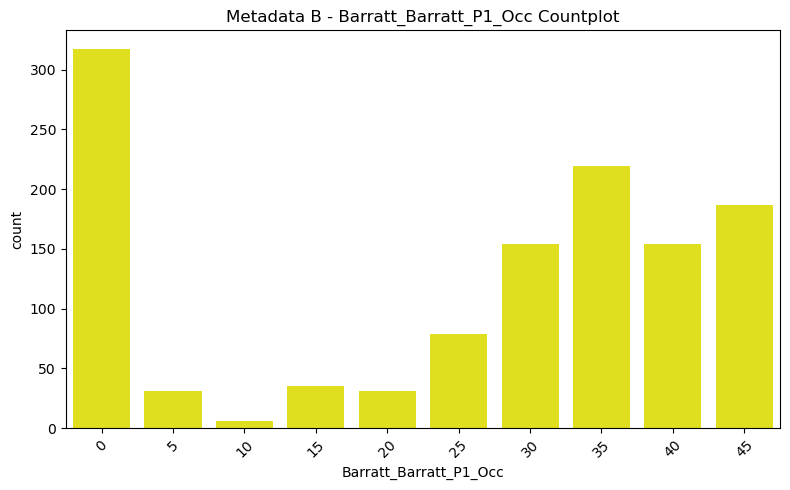

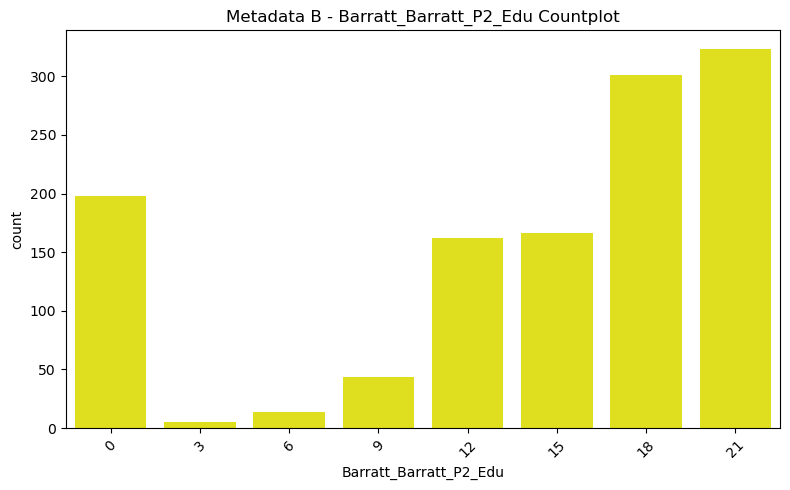

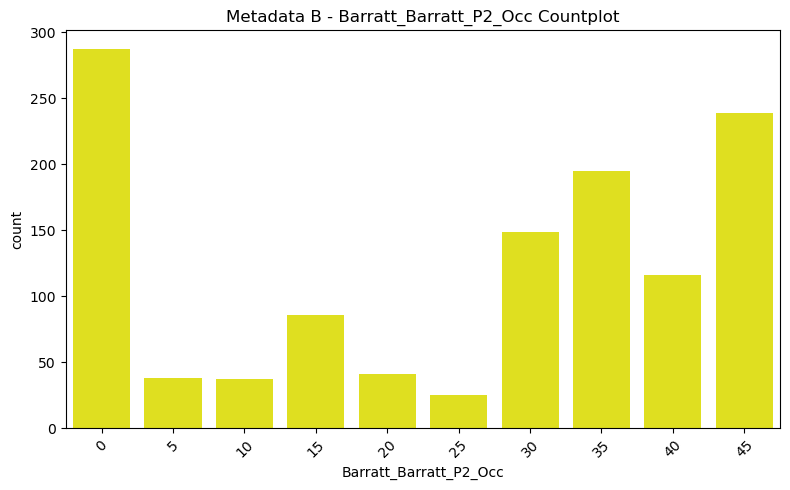

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# My data path
data_dir = "../data"
path_meta_b = os.path.join(data_dir, "METADATA_B.xlsx")

metadata_b_df = pd.read_excel(path_meta_b)

sns.set_palette("pastel")

# I set the function to explore categorical metadata
def explore_categorical_dataframe(df, title_prefix=""):
    
    print("DataFrame Info:\n")
    df.info()
    print("\n")

    # Here I show value counts for each column
    for col in df.columns:
        if col != "participant_id":
            print(f"Value Counts for Column: {col}")
            print(df[col].value_counts(dropna=False))
            print("\n")

    # This section shows missing values
    print("Missing Values Per Column:")
    print(df.isnull().sum())
    print("\n")

    # Plot countplots
    categorical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col != "participant_id"]

    for col in categorical_cols:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=col, color='yellow')
        plt.title(f"{title_prefix} - {col} Countplot")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# This code is about calling my function on Metadata B
explore_categorical_dataframe(metadata_b_df, title_prefix="Metadata B")


# Analysis of Metadata B

**1. Basic_Demos_Enroll_Year**

The maximum number of participants was about (415) in 2018, the 2019 and 2017 groups enrolled next maximum. Very few participants in the 2015 group about (40) reported and about 5 in the 2020 group. The data contribution from each year is not even.

**2. Basic_Demos_Study_Site**

The number of participants differed considerably based on the study sites. Over half of the participants (650) were from site 1 while site 3 had about 430 and the other one means 4 had about 120 participants. Site 2 has not gotten many participants. It has an extremely small number which is about 10. If the site variable correlates with an outcome or feature that is important, this bias can influence the model. This needs to be considered while splitting or training. 

**3. PreInt_Demos_Fam_Child_Ethnicity**

Most of the values are in the 0.0 category and not that much about 800 and few missing values 11. Entries of category 1.0 are about (300). There are very few quantities per category so most of the entries are missing. The model may have difficulty learning this variation for small groups, so they must be careful during preprocessing.

**4. PreInt_Demos_Fam_Child_Race**

The most common race category is 0 about (630), while some categories such as 7 and 11 have less than 5 entries. The data has many instances of a specific category that the model will overfit with. If not checked, it will treat the category as the only one in the inputs.

**5. MRI_Track_Scan_Location**

Scan locations 2 and 3 have the most participants (nearly 500), while locations 0 and 4 have the least participants. Some locations get more scans done which impacts the quality and consistency of scans. 

**6. Barratt_Barratt_P1_Edu**

Most of the values for Parent 1’s education level are 18 and 21 years which constitute higher education levels. A lot fewer participants received scores for the lesser education levels such as 0, 3, 6, and 9 years. The data suggests that most of the participant parents have high education levels which can be considered a plus.  A sampling bias may account for this distribution making analysis on economic status or parental influence wrong.

**7. Barratt_Barratt_P1_Occ**

The data on Parent 1's Occupation is significantly skewed. The greatest number of entries, around 320, corresponded to the value 0, which is likely to be “unemployed” or an unknown category. Following that, categories 35 and 45 have higher frequencies, indicating the presence of different types of jobs. Most of the Parent 1 occupation data falls under category 0 (probably unknown) If categories like 5 and 10 have very few entries, this can limit the representation of those jobs.


**8. Barratt_Barratt_P2_Edu**

Levels 18 and 21 indicate that a person has completed higher studies. The lower education levels of 3 and 6 are low. This shows that the parents are leaning towards a higher education level. The comparative similarity of two parents may influence any analysis (for example family background, socio-economic status, or its influence on development outcome).

**9. Barratt_Barratt_P2_Occ**

The category 0 is the most famous and nearly 300 times and the low part is about categories 5, 10, 20, and 25. Many subjects represent similar backgrounds which indicates the value spread is not uniform.


# 5. Explore Brain Connectome
I look at Brain Connectome data which have fMRI-based connectivity matrices of high dimension. Each row contains data for a single participant while each column contains a unique connection.

## Key Exploration Goals:
- I look for **missing values**.
- I generate **summary statistics**.
- I look at how features are spread out.
- I create a visual with histograms that have the KDE curves for some sample columns.

## General Overview
- This dataset has 1213 rows and 19901 columns.
- The numeric analysis involved dropping the **participant_id** column.
- There were no missing values in the Brain Connectome data set. 
- A few columns that are randomly selected show moderate skewness.
- Some selected features are normally distributed.
- KDE Curves help me visualize densities and identify skewness in my data.

Brain Connectome Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Columns: 19900 entries, 0throw_1thcolumn to 198throw_199thcolumn
dtypes: float64(19900)
memory usage: 184.2 MB


Missing Values (Total): 0


Statistical Summary:


,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
count,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,...,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000,1213.000000
mean,0.060553,0.122315,0.060268,0.041287,0.069722,0.091007,0.066852,0.000252,0.014128,-0.002914,...,0.011075,-0.004938,-0.004378,0.001610,0.115171,0.049984,0.058144,0.093527,0.089403,0.128946
std,0.064178,0.054026,0.057495,0.043491,0.044222,0.049189,0.046864,0.049046,0.038205,0.042462,...,0.049632,0.046536,0.042900,0.047424,0.057128,0.051664,0.057674,0.054594,0.058036,0.058490
min,-0.183279,-0.059932,-0.145566,-0.127827,-0.072043,-0.079184,-0.105722,-0.164297,-0.137728,-0.148490,...,-0.161666,-0.176523,-0.178688,-0.138048,-0.070094,-0.153540,-0.131455,-0.085566,-0.204160,-0.083077
25%,0.018482,0.086102,0.026548,0.014457,0.042462,0.057614,0.036934,-0.031358,-0.010635,-0.030538,...,-0.021376,-0.033424,-0.033798,-0.030132,0.080291,0.015827,0.022316,0.059621,0.053224,0.090459
50%,0.058276,0.123220,0.061339,0.043246,0.067066,0.086494,0.067247,0.002549,0.016130,-0.002604,...,0.010254,-0.004683,-0.003724,0.000990,0.113640,0.052705,0.059151,0.093397,0.088612,0.127913
75%,0.100103,0.154518,0.099056,0.068408,0.096504,0.119404,0.095117,0.031053,0.038770,0.024507,...,0.044165,0.024913,0.024007,0.032268,0.150524,0.082526,0.095192,0.127144,0.127613,0.166523
max,0.321522,0.390895,0.278429,0.189825,0.317500,0.316811,0.270018,0.168196,0.145364,0.128301,...,0.194616,0.183152,0.180562,0.192015,0.375635,0.228748,0.322084,0.348153,0.267162,0.414304




Value Range (Min & Max across all features):
Min: -0.3768, Max: 0.7391


Skewness of a few sample columns:
0throw_1thcolumn: Skewness = 0.1578
0throw_2thcolumn: Skewness = 0.3983
0throw_3thcolumn: Skewness = -0.1490
0throw_4thcolumn: Skewness = -0.1916
0throw_5thcolumn: Skewness = 0.3328


Histograms for a few random features with KDE line:


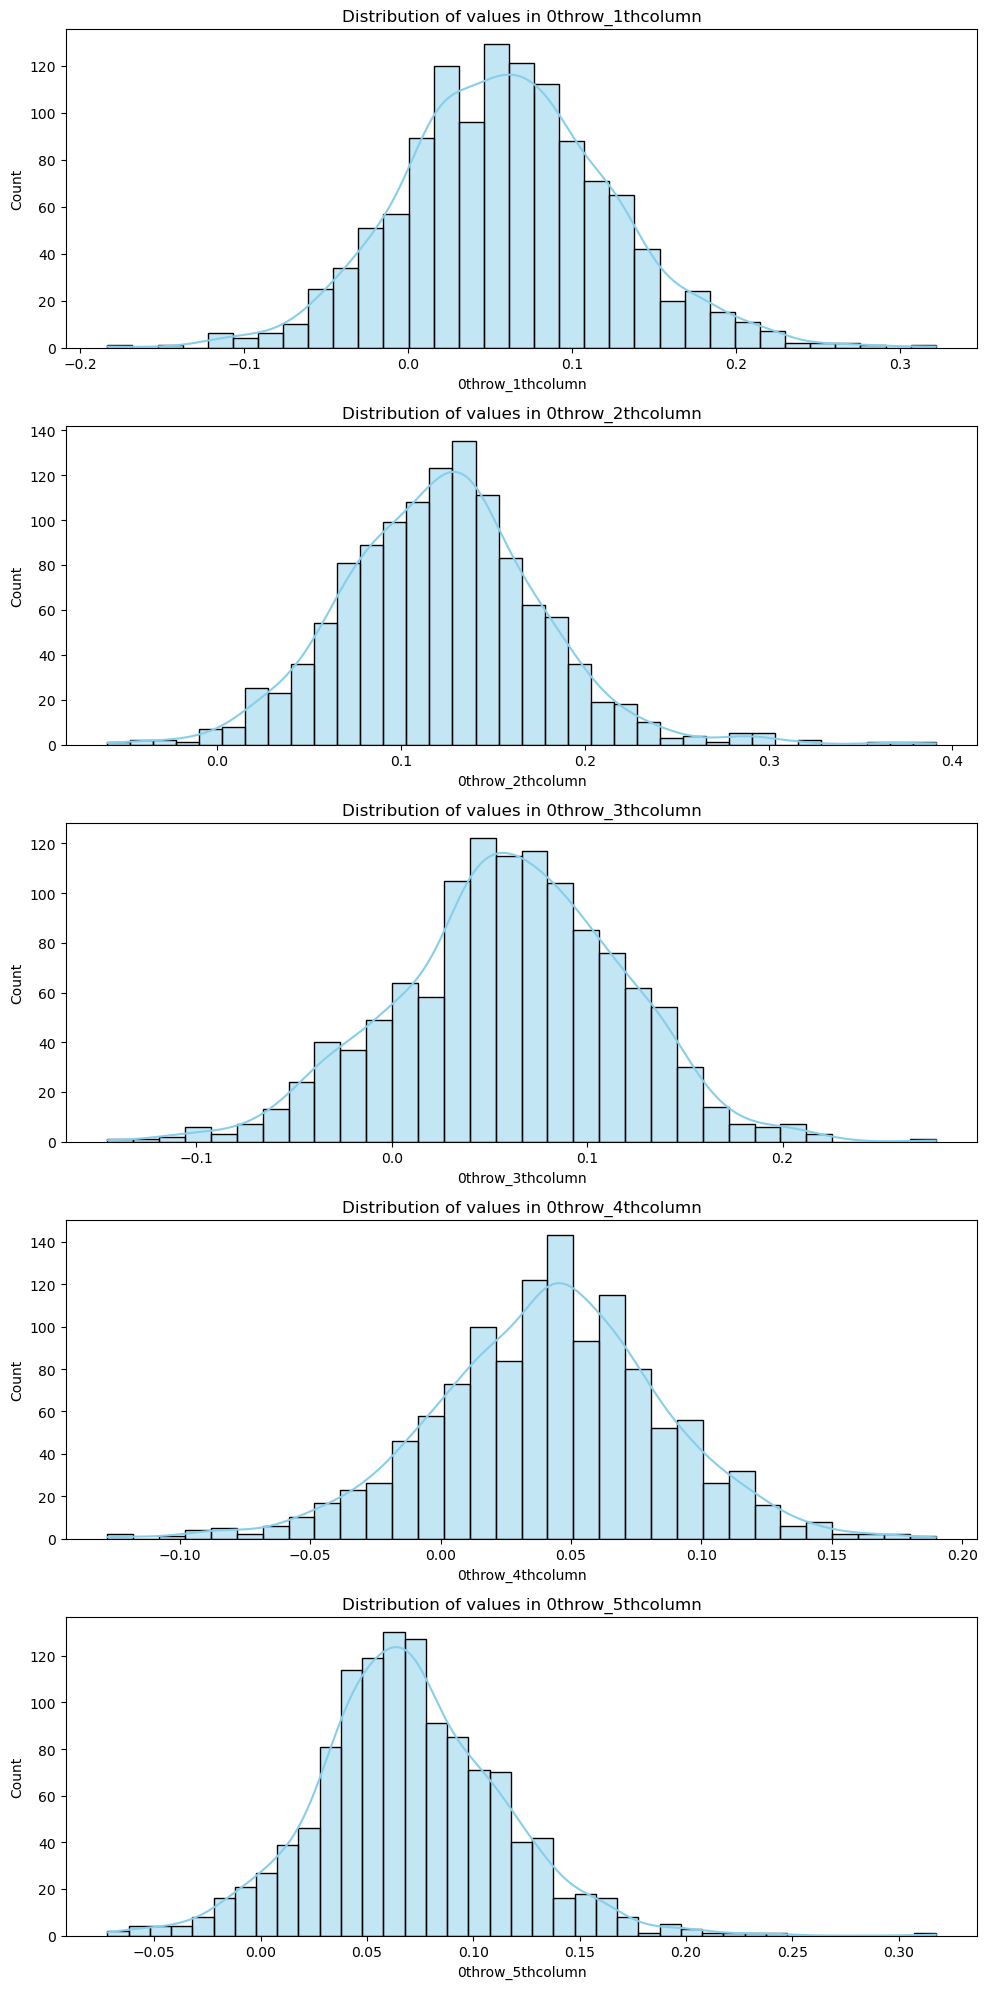

Heatmap for first participant's connectome matrix:


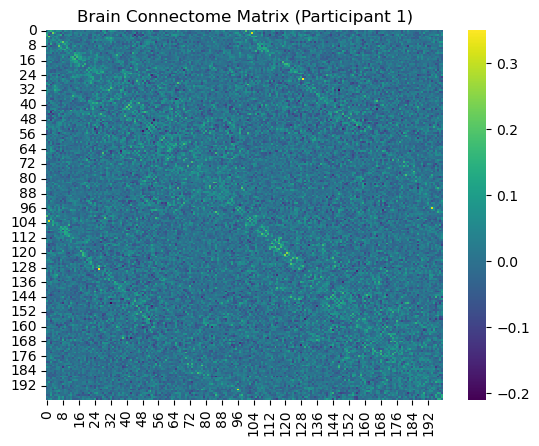

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# My data path
data_path = "../data/FUNCTIONAL_CONNECTOME_MATRICES.csv"
connectome_df = pd.read_csv(data_path)

# I drop participant_id from brain connectome data because this feature is not a numerical column
if 'participant_id' in connectome_df.columns:
    numeric_df = connectome_df.drop(columns=['participant_id'])
else:
    numeric_df = connectome_df.copy()

def vector_to_symmetric_matrix(vec, dim):
    matrix = np.zeros((dim, dim))
    upper_indices = np.triu_indices(dim, k=1)
    matrix[upper_indices] = vec
    matrix = matrix + matrix.T  
    return matrix

# I set the function to explore connectome data
def explore_connectome_dataframe(df, sample_size=5):
    print("Brain Connectome Data Info:\n")
    df.info()
    print("\n")

    print("Missing Values (Total):", df.isnull().sum().sum())
    print("\n")

    print("Statistical Summary:")
    display(df.describe())
    print("\n")

    print("Value Range (Min & Max across all features):")
    print(f"Min: {df.min().min():.4f}, Max: {df.max().max():.4f}")
    print("\n")

    print("Skewness of a few sample columns:")
    sample_cols = df.columns[:sample_size]
    for col in sample_cols:
        print(f"{col}: Skewness = {df[col].skew():.4f}")
    print("\n")

    print("Histograms for a few random features with KDE line:")
    fig, axs = plt.subplots(nrows=sample_size, figsize=(10, 4 * sample_size))
    for i, col in enumerate(sample_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axs[i], color='skyblue', edgecolor='black')
        axs[i].set_title(f"Distribution of values in {col}")
    plt.tight_layout()
    plt.show()

    print("Heatmap for first participant's connectome matrix:")
    try:
        dim = 200 
        if df.shape[1] == dim * (dim - 1) // 2:
            matrix = vector_to_symmetric_matrix(df.iloc[0].values, dim)
            sns.heatmap(matrix, cmap='viridis')
            plt.title("Brain Connectome Matrix (Participant 1)")
            plt.show()
        else:
            print(f"Column count {df.shape[1]} doesn't match expected vector length for a symmetric matrix.")
    except Exception as e:
        print(f"Error reshaping matrix: {e}")

# This code is about calling my function on FUNCTIONAL_CONNECTOME_MATRICES
explore_connectome_dataframe(numeric_df)

# Analysis of Brain Connectome

## Summary Statistics
- The average and the standard deviation are quite low. As with any normalized fMRI connectivity values, I expect them to be close to zero with a small variation.

## Skewness & Distribution
I reviewed 5 random features and calculated their skewness.
- The five columns have very low skewness values, i.e. around -0.15 and 0.33. This means that the values of these five features are approximately symmetrically distributed.

The histograms accompanied by the KDE lines verify this.
- The larger portion of the sampled results features a normal distribution.
- This is a good thing because it backs up the use of statistical methods that assume normality.

## Visualization
- Most of the sample connections’ histogram with the kernel density estimate curve looks like a normal distribution.
- Due to the number of features (19901) not being a perfect square, we could not plot a heatmap of the first subject’s connectivity matrix as a square matrix.

## Matrix Structure (200 × 200):
- The given image is of one reconstructed participant’s brain connectome.
- The 200×200 matrix suggests that the brain has been divided into 200 areas.
- Each box shows how strong the connection is between regions in the brain.

## Symmetry of the Matrix:
- The brain’s connection from A to B or vice versa is the same. Thus, the matrix should be perfectly symmetric which more or less is.
- This proves that the triangular vector was reshaped correctly via the proper use of np.triu_indices.

## Color Scale and Interpretation:
- A combination of **blue shades** is put to use that usually indicates negative or weak connections.
- **Green colors** are more positive in nature.
- The shading of colors ranges from -0.2 to +0.35, matching the summary stats printed above.

# 6. Explore Labels

- My dataset includes the following columns:
- The target label shows if the individual **has ADHD or not**.
- The participant's **gender/sex** is a factor in the analysis ADHD 1 shows female and 0 shows male.

I check the following to receive better information:
- Each column’s count of non-null values.
- The number of unique values.
- Total number of values for each label.
- Bar plots can visualize how ADHD_Outcome and Sex_F are distributed.
- A combined column plot for participant distribution among **Sex_F** and **ADHD_Outcome**.

Labels Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   participant_id  1213 non-null   object
 1   ADHD_Outcome    1213 non-null   int64 
 2   Sex_F           1213 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 28.6+ KB

 Unique values per column:
participant_id: ['UmrK0vMLopoR' 'CPaeQkhcjg7d' 'Nb4EetVPm3gs' ... 'zmxGvIrOD0bt'
 'rOmWFuJCud5G' 'k8HhHnnu2wmt']
ADHD_Outcome: [1 0]
Sex_F: [1 0]


 Value counts:

ADHD_Outcome:
ADHD_Outcome
1    831
0    382
Name: count, dtype: int64

Sex_F:
Sex_F
0    797
1    416
Name: count, dtype: int64

 Plotting value counts:


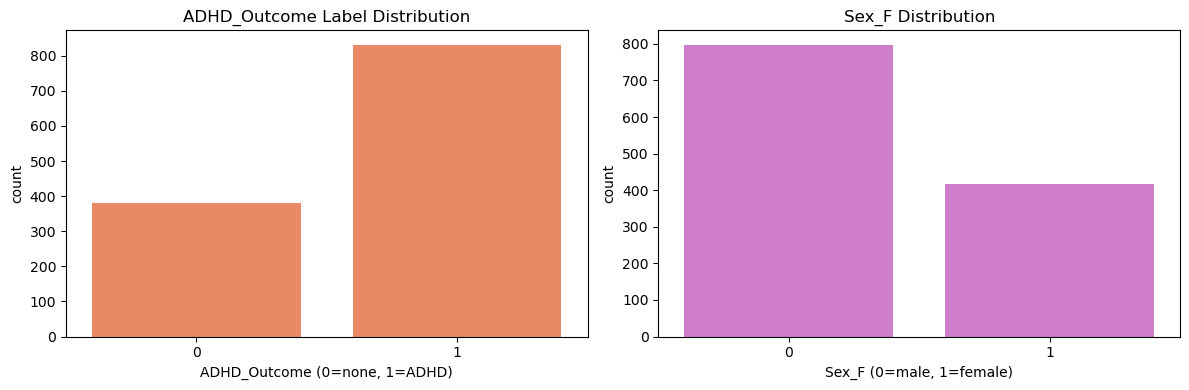


 Combined Sex_F + ADHD_Outcome groups:
 combined
0_1    581
1_1    250
0_0    216
1_0    166
Name: count, dtype: int64


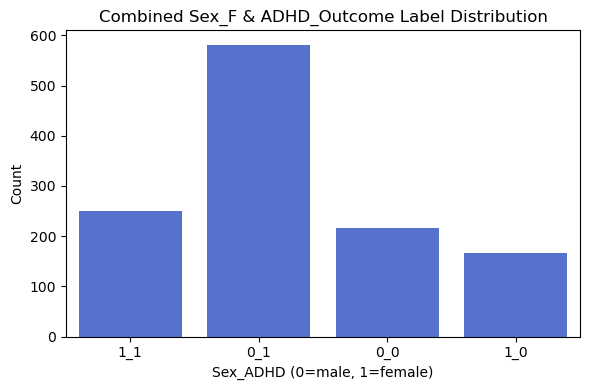

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_dir = "../data"
labels_path = os.path.join(data_dir, "LABELS.xlsx")
labels_df = pd.read_excel(labels_path)

# I write this code to show function to explore labels
def explore_labels(df):
    print("Labels Data Info:")
    df.info()
    print("\n Unique values per column:")
    for col in df.columns:
        print(f"{col}: {df[col].unique()}")
    print("\n")

    print(" Value counts:")
    for col in ['ADHD_Outcome', 'Sex_F']:
        print(f"\n{col}:\n{df[col].value_counts()}")

    print("\n Plotting value counts:")

    plt.figure(figsize=(12, 4))

    # This code is for ADHD plot
    plt.subplot(1, 2, 1)
    sns.countplot(data=df, x='ADHD_Outcome', color='coral')
    plt.title("ADHD_Outcome Label Distribution")
    plt.xlabel("ADHD_Outcome (0=none, 1=ADHD)")

    # This code is for Sex plot
    plt.subplot(1, 2, 2)
    sns.countplot(data=df, x='Sex_F', color='orchid')
    plt.title("Sex_F Distribution")
    plt.xlabel("Sex_F (0=male, 1=female)")

    plt.tight_layout()
    plt.show()

    # I combined label plot
    df['combined'] = df['Sex_F'].astype(str) + "_" + df['ADHD_Outcome'].astype(str)
    print("\n Combined Sex_F + ADHD_Outcome groups:\n", df['combined'].value_counts())

    plt.figure(figsize=(6, 4))
    sns.countplot(x='combined', data=df, color='royalblue')
    plt.title("Combined Sex_F & ADHD_Outcome Label Distribution")
    plt.xlabel("Sex_ADHD (0=male, 1=female)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# This code is about calling my function on Labels
explore_labels(labels_df)


# Analysis of labels
## ADHD_Outcome Distribution:
- 831 people with value 1 (ADHD positive diagnosis).
- 0 value no ADHD positive linear type appears 382 times
- I can see a clear class imbalance here, with twice as many ADHD-positive cases as non-ADHD.

## Sex_F Distribution:
- Value 0 **(male)** is used 797 times
- Value 1 **(Female)** is used also 416 times.
- There is a difference between boys and girls, and this difference is a huge one like the difference in ADHD.

## Combined Label Distribution:
- This group 0-1 is males with ADHD = 581.
- This group 1-1 is females with ADHD = 250.
- This group 0-0 is males without ADHD = 216.
- This group 1-0 is females without ADHD = 166.

## I found this information from the data:
- Most of the people are boys with ADHD.
- The least number of people are female without ADHD.
- Also, gender bias might be introduced in the model. Specifically, for the smaller group (non-ADHD females), the prediction may negatively affect the performance of that group.


# 7.Preprocessing Planning
## 7.1 Merging datasets
I merge the 4 main datasets into one set. In this case, I use the unique participant_id as a key. 

**My datasets include:**
- **LABELS.xlsx**
- **METADATA_A.xlsx**
- **METADATA_B.xlsx**
- **FUNCTIONAL_CONNECTOME_MATRICES.csv**

I use pd.merge() instead of pd.concat() in order to make sure they align by participant IDs since the order of rows might differ.

Here are all of the steps in my process:
- I load each dataset into a separate pandas DataFrame.
- I merge in steps on the participant_id to get all of them aligned correctly.
- I show the shape of the merged dataset and check for any missing values.

In [16]:
import pandas as pd

# This part is about loading the datasets
labels_df = pd.read_excel("../data/LABELS.xlsx")
meta_a_df = pd.read_excel("../data/METADATA_A.xlsx")
meta_b_df = pd.read_excel("../data/METADATA_B.xlsx")
connectome_df = pd.read_csv("../data/FUNCTIONAL_CONNECTOME_MATRICES.csv")

# I merge them step-by-step on 'participant_id'
merged_df = labels_df.merge(meta_a_df, on='participant_id')
merged_df = merged_df.merge(meta_b_df, on='participant_id')
merged_df = merged_df.merge(connectome_df, on='participant_id')

# I want to see general information in this section
print(f"Final merged shape: {merged_df.shape}")
print("\nAny missing values?", merged_df.isnull().sum().sum())
merged_df.head()


Final merged shape: (1213, 19930)

Any missing values? 371


,participant_id,ADHD_Outcome,Sex_F,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,UmrK0vMLopoR,1,1,40.00,13,3,10,47,13,11,...,-0.037630,-0.072599,-0.058396,-0.041544,0.142806,-0.006377,0.108005,0.148327,0.093230,-0.004984
1,CPaeQkhcjg7d,1,0,-94.47,14,3,13,34,18,23,...,0.014106,-0.001084,-0.025624,-0.031863,0.162011,0.067439,0.017155,0.088893,0.064094,0.194381
2,Nb4EetVPm3gs,1,0,-46.67,14,4,10,35,16,10,...,-0.040456,0.018640,0.010771,-0.044341,0.128386,0.047282,0.087678,0.146221,-0.009425,0.035150
3,p4vPhVu91o4b,1,1,-26.68,10,5,12,39,19,16,...,-0.016356,0.025618,-0.007152,0.032584,0.121726,0.045089,0.154464,0.106817,0.065336,0.234708
4,M09PXs7arQ5E,1,1,0.00,14,5,15,40,20,24,...,-0.056285,-0.031508,-0.010196,0.035638,0.074978,0.030579,0.025640,0.118199,0.112522,0.143666


# Analysis of merging datasets

- I have data of 1213 participants in total and 19930 columns which include both metadata and brain connectivity features.
- There are 371 missing values. These are present across some metadata columns but not connectome columns.
- The **first** Column structure include the Participant ID, ADHD_Outcome, Sex_F, and several metadata fields.
- The **final** columns include: There are 19900 brain connectome features that are titled 0throw_1thcolumn, …, up to 198throw_199thcolumn.

## 7.2 Splitting Data

I split my dataset into train and test sets for modeling. The test set has an equal distribution of the target labels (stratified split with target labels).

The steps that I do in this stage:

1.**Created a Combined Label (Sex_ADHD):**
To make a stratified split, I add a new column as a combination of Sex_F and ADHD_Outcome. This lets me keep the balance of different groups (Females with ADHD, Males without ADHD), in the train and test.

2.**Displayed Label Distribution:**
I counted how many samples fell under each label combination.
- **0_0:** Male, non-ADHD.
- **0_1:** Male, ADHD.
- **1_0:** Female, non-ADHD.
- **1_1:** Female, ADHD.
This helped me show that the counts of samples in every class are not equal before splitting.

3. **Stratified Train-Test Split (70%-30%):**
I used **train_test_split** with the **stratify=Sex_ADHD** option to split the merged dataset to ensure that all label combinations are represented. The random_state=42 ensures reproducibility.

4. **Displayed Shapes and Percentages:**
I printed the count of samples in the training and test set which was 70–30.

In [18]:
from sklearn.model_selection import train_test_split

# I Create a combined label using 'Sex_F' and 'ADHD_Outcome' for stratified split
merged_df['Sex_ADHD'] = merged_df['Sex_F'].astype(str) + "_" + merged_df['ADHD_Outcome'].astype(str)

# I try to show the distribution of combined labels
print("Combined label counts:")
print(merged_df['Sex_ADHD'].value_counts())

# Here is the mapping for an explanation
label_explanation = {
    "0_0": "Male, non-ADHD",
    "0_1": "Male, ADHD",
    "1_0": "Female, non-ADHD",
    "1_1": "Female, ADHD"
}


print("\nDetailed label explanation:")
for label, count in merged_df['Sex_ADHD'].value_counts().items():
    explanation = label_explanation.get(label, "Unknown")
    print(f"{label}: {explanation} — {count} participants")

# Here is performed stratified train-test split based on the combined label
train_df, test_df = train_test_split(
    merged_df,
    test_size=0.3,  # 30% test, 70% train
    stratify=merged_df['Sex_ADHD'],
    random_state=42
)

# I show shapes of the splits
print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Here I want to print the percentage of train and test sets
total_samples = len(merged_df)
print(f"\nTrain set: {len(train_df)} samples ({len(train_df)/total_samples:.1%})")
print(f"Test set: {len(test_df)} samples ({len(test_df)/total_samples:.1%})")

# I check for overlap in participant_id
train_ids = train_df['participant_id'].tolist()
test_ids = test_df['participant_id'].tolist()
overlap = set(train_ids) & set(test_ids)

print("\nChecking for participant overlap...")
if len(overlap) == 0:
    print("No overlap between train and test sets.")
else:
    print(f"Warning: {len(overlap)} overlapping participants found!")
    print("Example overlapping IDs:", list(overlap)[:5])




Combined label counts:
Sex_ADHD
0_1    581
1_1    250
0_0    216
1_0    166
Name: count, dtype: int64

Detailed label explanation:
0_1: Male, ADHD — 581 participants
1_1: Female, ADHD — 250 participants
0_0: Male, non-ADHD — 216 participants
1_0: Female, non-ADHD — 166 participants

Train shape: (849, 19931)
Test shape: (364, 19931)

Train set: 849 samples (70.0%)
Test set: 364 samples (30.0%)

Checking for participant overlap...
No overlap between train and test sets.


# Analysis of Splitting Data

1. **Sex_ADHD label** is combined and in distribution:
- 0_1 The number of people that they are male with ADHD is 581.
- 1_1 The number of people that they are female with ADHD is 250.
- 0_0 The number of people who are male without ADHD is 216.
- 1_0 The number of people who are female without ADHD is 166.
- This means that there are a lot more members from some groups than others. The dataset is unbalanced. Male subjects with ADHD represent the largest group, while female subjects without ADHD represent the smallest.

2. **Train–Test** Split Summary:
- The training set contains 849 Samples in (70%)
- The test set contains 364 samples in (30%)
- The 70/30 split ratio defined by the test_size=0.3 parameter is what I expect.

3. Checking for Participant **Overlap**:
- My output confirms that train and test sets do not overlap.
- This confirms that no participant is present in both training and testing sets, preventing participant overlap and reducing data-leakage risk.

# 7.3 Preprocessing Metadata A
I cleaned and prepared the numerical Metadata A before using it in the model. 

**Here's the task that I will do:**
- I extract metadata A features.
- I verified the existence of missing values in each feature in the training data. This helped me identify columns with missing values that required treatment or completion.
- I check how the data is distributed in a column with missing values before I fill in the missing values. This helped me understand the data pattern and decide how to fill in the empty cells.
- I use KNNImputer with K=5 to fill in missing values This technique predicts missing values using similar other participants in the dataset.
- I check the relationship between the numerical features by creating a Correlation Matrix. Analyzing correlation can be useful when I start looking at feature selection. Some variables may be very similar to others.

Missing values in Metadata A (train set):
MRI_Track_Age_at_Scan    254
dtype: int64


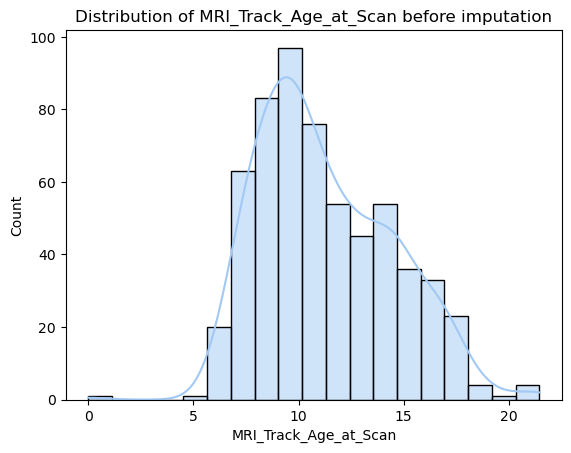


Missing values after imputation (should be zero):
0 in train
0 in test


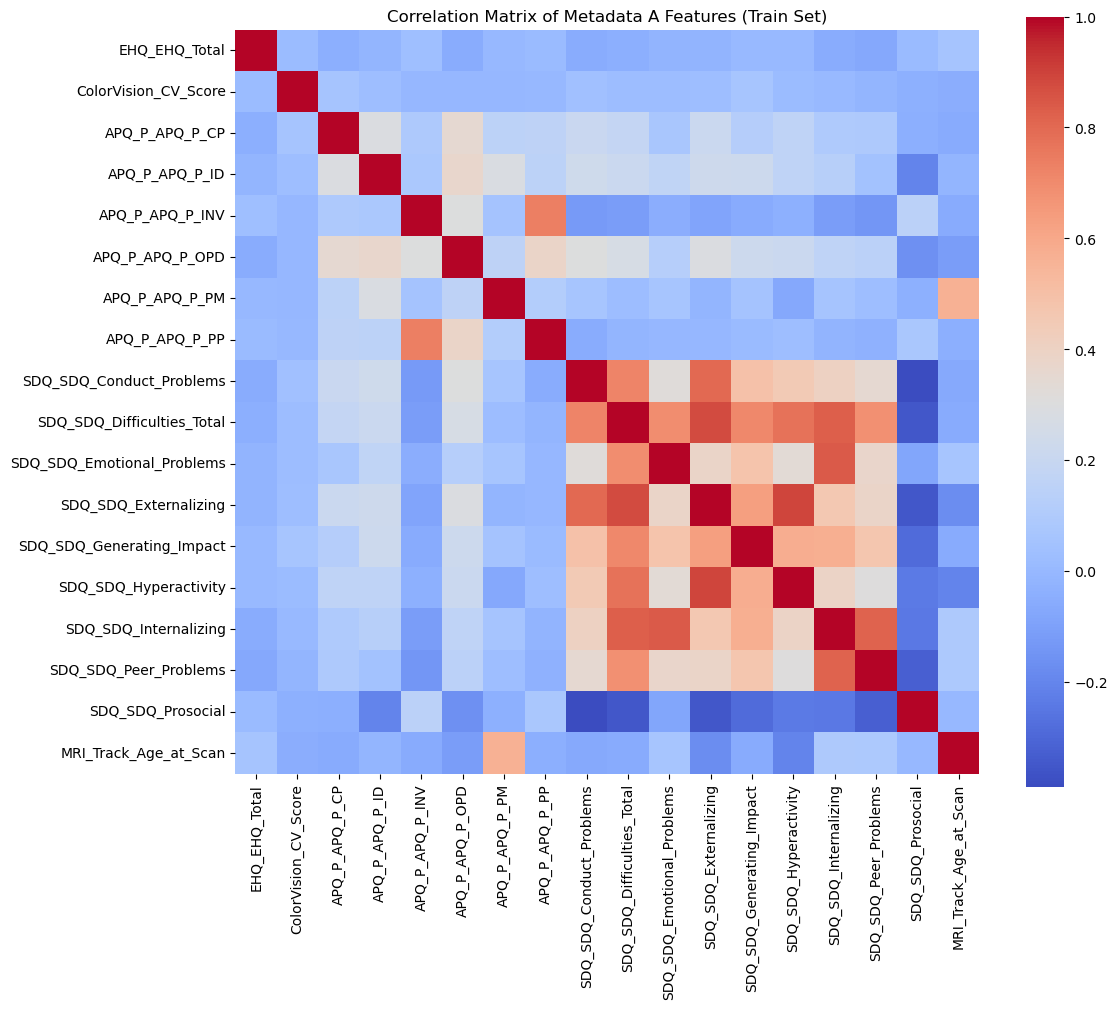

In [20]:
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt

# I take the Metadata A features from train and test sets
meta_a_columns = meta_a_df.columns.drop('participant_id')
train_meta_a = train_df[meta_a_columns].copy()
test_meta_a = test_df[meta_a_columns].copy()

# I check missing values
print("Missing values in Metadata A (train set):")
print(train_meta_a.isnull().sum()[train_meta_a.isnull().sum() > 0])

# Visualize distribution of missing column (MRI_Track_Age_at_Scan)
col_with_missing = 'MRI_Track_Age_at_Scan'
sns.histplot(train_meta_a[col_with_missing], kde=True)
plt.title(f"Distribution of {col_with_missing} before imputation")
plt.xlabel(col_with_missing)
plt.ylabel("Count")
plt.show()

# I try to fill in missing values with the use of KNNImputer
imputer = KNNImputer(n_neighbors=5)
train_meta_a_imputed = pd.DataFrame(imputer.fit_transform(train_meta_a), columns=meta_a_columns, index=train_meta_a.index)
test_meta_a_imputed = pd.DataFrame(imputer.transform(test_meta_a), columns=meta_a_columns, index=test_meta_a.index)

# I checked again to ensure no missing values
print("\nMissing values after imputation (should be zero):")
print(train_meta_a_imputed.isnull().sum().sum(), "in train")
print(test_meta_a_imputed.isnull().sum().sum(), "in test")

# Here is the feature correlation heatmap
corr = train_meta_a_imputed.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False, square=True)
plt.title("Correlation Matrix of Metadata A Features (Train Set)")
plt.show()


# Analysis of Preprocessing Metadata A

- Only the MRI_Track_Age_at_Scan column had missing values.
- A total of 254 values were missing in this column, and they were successfully filled using KNNImputer.
- Once the filling is complete; its output confirms that there are **zero** missing values in train and test.
  
- Before that I want to fill in MRI_Track_Age_at_Scan, the histogram of MRI_Track_Age_at_Scan showed a normal distribution.
- The peak looks to be around 1o years old, which seems reasonable considering this dataset focuses on children and adolescents.

- Some features, especially from the SDQ group (like Externalizing, Hyperactivity, and Difficulties_Total), show strong correlations.
- These features may have overlapping information and I can try to reduce their replication at the variable selection stage.

# Feature Selection with Mutual Information Metadata A

I used statistical methods of Mutual Information to choose the most Significant Features from the Cleaned Metadata A. This functionality ensures that I only keep the features and not extra details that are not useful.
1. I separated the features (X_train) and the target label (y_train).
2. I calculated Mutual Information scores for each feature. The higher the score the more useful piece of information the feature is for the label.
3. I sorted the features based on these scores and picked the top 10.
4. I filtered train and test sets to keep only these top features.

In [22]:
from sklearn.feature_selection import mutual_info_classif

# Wrting this codes for separate features (X) and labels (y)
X_train = train_meta_a_imputed.copy()
y_train = train_df['ADHD_Outcome']  

# With this code I can compute Mutual Information scores
mi_scores = mutual_info_classif(X_train, y_train, discrete_features=False, random_state=42)

#  Creating a data frame of scores
mi_df = pd.DataFrame({'Feature': X_train.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

# I'm showing the top 10 features
print("Top 10 features based on Mutual Information:")
display(mi_df.head(10))

# I select top-k features
top_k = 10
selected_features = mi_df['Feature'].iloc[:top_k].tolist()


# I filter the train and test sets based on selected features
train_meta_a_selected = train_meta_a_imputed[selected_features].copy()
test_meta_a_selected = test_meta_a_imputed[selected_features].copy()


Top 10 features based on Mutual Information:


,Feature,MI_Score
13,SDQ_SDQ_Hyperactivity,0.170365
11,SDQ_SDQ_Externalizing,0.135395
9,SDQ_SDQ_Difficulties_Total,0.122854
8,SDQ_SDQ_Conduct_Problems,0.068064
12,SDQ_SDQ_Generating_Impact,0.059478
14,SDQ_SDQ_Internalizing,0.040045
3,APQ_P_APQ_P_ID,0.038325
4,APQ_P_APQ_P_INV,0.031737
10,SDQ_SDQ_Emotional_Problems,0.024287
15,SDQ_SDQ_Peer_Problems,0.010322


# Analysis of Feature Selection with Mutual Information

I took the top 10 features from the output that are the most useful for predicting ADHD. The scores indicate the contributions of the features towards understanding the target variable.

**Key Observations:**
- Out of all the good related features, SDQ_SDQ_Hyperactivity is the most useful one in relation to ADHD. It is quite logical, as hyperactivity is one of the main characteristics of ADHD.
- SDQ_SDQ_externalizing, difficulties total, conduct problems and internalizing are also completely useful. These features are representative of behaviors and emotions that are typically observed with ADHD.
- Items from the parental questionnaire (APQ_P_APQ_P_ID and APQ_P_INV) also get selected but with less effect. This suggests that while parental views are useful, they are less associated with ADHD diagnosis than behaviors. 
- Some of the features that got low scores like SDQ_SDQ_Peer_Problems and SDQ_SDQ_Emotional_Problems made it to the top-10. This shows that they might contribute in combination with other features, although not highly informative alone.

# 7.4 Preprocessing Metadata B

I already cleaned up and prepared the categorical Metadata B for use in the model.

1. Extract features: Initially, I selected useful columns from Metadata B **except participant_id** for train and test.
2. Check for missing values: I looked for the null values in the train Data.
3. Fill in missing values: According to the Data Dictionary, I replaced all the missing values with 3, which indicates Unknown.
4. Confirm data completeness: I make sure that there is no missing data left in train and test datasets after filling.

In [24]:
import pandas as pd

meta_b_df = pd.read_excel("../data/METADATA_B.xlsx")

# I extract Metadata B columns from train and test sets
meta_b_columns = meta_b_df.columns.drop('participant_id')
train_meta_b = train_df[meta_b_columns].copy()
test_meta_b = test_df[meta_b_columns].copy()

#  Check the missing values
print("Missing values in Metadata B (train set):")
print(train_meta_b.isnull().sum()[train_meta_b.isnull().sum() > 0])

# Acoording to general feedback I should fill missing values with 3 (meaning "Unknown" based on the Data Dictionary)
train_meta_b_filled = train_meta_b.fillna(3)
test_meta_b_filled = test_meta_b.fillna(3)

# To make sure all missing values are filled
print("\nMissing values after filling:")
print(f"{train_meta_b_filled.isnull().sum().sum()} in train")
print(f"{test_meta_b_filled.isnull().sum().sum()} in test")

# I visualize value distribution for each column
for col in meta_b_columns:
    print(f"\nValue counts for {col} (train set):")
    print(train_meta_b_filled[col].value_counts())


Missing values in Metadata B (train set):
PreInt_Demos_Fam_Child_Ethnicity    9
dtype: int64

Missing values after filling:
0 in train
0 in test

Value counts for Basic_Demos_Enroll_Year (train set):
Basic_Demos_Enroll_Year
2018    273
2019    222
2017    185
2016    143
2015     23
2020      3
Name: count, dtype: int64

Value counts for Basic_Demos_Study_Site (train set):
Basic_Demos_Study_Site
1    463
3    293
4     84
2      9
Name: count, dtype: int64

Value counts for PreInt_Demos_Fam_Child_Ethnicity (train set):
PreInt_Demos_Fam_Child_Ethnicity
0.0    564
1.0    206
2.0     58
3.0     21
Name: count, dtype: int64

Value counts for PreInt_Demos_Fam_Child_Race (train set):
PreInt_Demos_Fam_Child_Race
0     425
8     143
1     126
2      91
3      21
9      19
10     11
4       8
11      3
7       2
Name: count, dtype: int64

Value counts for MRI_Track_Scan_Location (train set):
MRI_Track_Scan_Location
2    372
3    319
1    129
4     27
0      2
Name: count, dtype: int64

Value co

# Analysis of Preprocessing Metadata B
1. **Missing Values Handling**
- The column (PreInt_Demos_Fam_Child_Ethnicity) has a total of 9 missing values.
- I used value 3 to fill these blanks which (as per the data dictionary) refers to Unknown.
- After the filling-in process, neither the train nor the test set has missing values anymore.

2. **Value Distribution**
- Most of the columns will have more than two unique categories as per value_counts().
- Some categories have a huge imbalance (e.g. Basic_Demos_Study_Site) has 463 entries for one site but only 9 for another.

3. **Interpretation for Modeling**
- Whether a category is imbalanced may affect how a model learns it through encoding.
- As most of them are encoded in integer form it’s better to treat them as categorical.

# Feature Selection with Mutual Information Metadata B

I employed Mutual Information to select the most important features of the categorical dataset (Metadata B) relevant to ADHD outcomes. This will help identify features that share the most information with ADHD.

1. Prepared Input Data:
- The input features are from the cleaned and imputed version of Metadata B.
- The outcome that I wanted was ADHD.

2. Calculated Mutual Information:
- I used mutual_info_classif from sklearn.feature_selection with discrete_features=True since it is categorical.
- This helped me to find how informative a given feature is for the target.

3. Selected Top Features:
- I want to make a data frame of the features and MI scores.
- I will arrange the features based on their scores.
- I choose the top eight features for further modeling.

4. Filtered Data:
- I filter the train and test sets for the selected features only.

In [26]:
from sklearn.feature_selection import mutual_info_classif

# Preparing the  X and y
X_b = train_meta_b_filled.copy()
y_b = train_df['ADHD_Outcome']

# I'm computing the Mutual Information scores
mi_scores_b = mutual_info_classif(X_b, y_b, discrete_features=True, random_state=42)

# So, I put them into DataFrame
mi_df_b = pd.DataFrame({
    'Feature': X_b.columns,
    'MI_Score': mi_scores_b
}).sort_values(by='MI_Score', ascending=False)

# I want to show the top features
print("Top features from Metadata B based on Mutual Information:")
display(mi_df_b.head(8))

# selecting the top-k features (top 8)
top_k_b = 8
selected_meta_b_features = mi_df_b['Feature'].iloc[:top_k_b].tolist()

# I filter train and test sets based on selected features
train_meta_b_selected = train_meta_b_filled[selected_meta_b_features].copy()
test_meta_b_selected = test_meta_b_filled[selected_meta_b_features].copy()


Top features from Metadata B based on Mutual Information:


,Feature,MI_Score
0,Basic_Demos_Enroll_Year,0.019807
4,MRI_Track_Scan_Location,0.015728
3,PreInt_Demos_Fam_Child_Race,0.007949
8,Barratt_Barratt_P2_Occ,0.004689
6,Barratt_Barratt_P1_Occ,0.004456
1,Basic_Demos_Study_Site,0.002902
5,Barratt_Barratt_P1_Edu,0.002465
2,PreInt_Demos_Fam_Child_Ethnicity,0.001118


# Analysis of Feature Selection with Mutual Information


The Mutual Information Scores helped me determine which categorical features in Metadata B are informative with respect to the ADHD label.

Top Scoring Features:
- The most informative categorical features were Basic_Demos_Enroll_Year & MRI_Track_Scan_Location.
- Top Features Are PreInt_Demos_Fam_Child_Race and PreInt_Demos_Fam_Child_Ethnicity
- Environmental factors appear to have contributed to this ADHD result and I could go further.

Considerations:
- The MI scores for these predictors are all quite low (less than 0.02), but that is typical of any categorical feature with a large number of levels.
- I select features using their individual relative importance scores.


# 7.5 Preprocessing Brain Connectome Data
I load the raw Brain Connectome Data. This data contains the fMRI-derived connectivity matrix of each participant, these are the data that we load first In this step I check the shape of the data, missing values and a first look at the data before preprocessing.


In [28]:
import pandas as pd

connectome_df = pd.read_csv("../data/FUNCTIONAL_CONNECTOME_MATRICES.csv")

# I check basic info
print("Connectome shape:", connectome_df.shape)
print("\nAny missing values =", connectome_df.isnull().sum().sum())

# Preview a few rows
connectome_df.head()

Connectome shape: (1213, 19901)

Any missing values = 0


,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,70z8Q2xdTXM3,0.093473,0.146902,0.067893,0.015141,0.070221,0.063997,0.055382,-0.035335,0.068583,...,0.003404,-0.010359,-0.050968,-0.014365,0.128066,0.112646,-0.058980,0.028228,0.133582,0.143372
1,WHWymJu6zNZi,0.029580,0.179323,0.112933,0.038291,0.104899,0.064250,0.008488,0.077505,-0.004750,...,-0.008409,-0.008479,0.020891,0.017754,0.094040,0.035141,0.032537,0.075007,0.115350,0.138200
2,4PAQp1M6EyAo,-0.051580,0.139734,0.068295,0.046991,0.111085,0.026978,0.151377,0.021198,0.083721,...,0.053245,-0.028003,0.028773,0.024556,0.166343,0.058925,0.035485,0.063661,0.042862,0.162162
3,obEacy4Of68I,0.016273,0.204702,0.115980,0.043103,0.056431,0.057615,0.055773,0.075030,0.001033,...,-0.023918,-0.005356,0.018607,0.016193,0.072955,0.130135,0.056120,0.084784,0.114148,0.190584
4,s7WzzDcmDOhF,0.065771,0.098714,0.097604,0.112988,0.071139,0.085607,0.019392,-0.036403,-0.020375,...,0.066439,-0.076680,-0.047530,-0.031443,0.221213,0.007343,0.005763,0.083820,0.079582,0.067269


# Analysis of Preprocessing Brain Connectome Data
- **Shape of the data:** (1213, 19901): there are 1213 participants, and each row has 19900 connectivity features plus one participant_id column.
- **Missing values:** 0: the dataset is complete and doesn’t need any missing value filling.


# Normalize Brain Connectome Features
In this step, I normalize the brain connectome features using StandardScaler. The participant_id column is dropped before scaling.
- **Goal:** I ensure all features are on the same scale.
- **Reason**: Standardization is critical for many ML algorithms to perform well, especially when features vary in range and units.
- I use z-score normalization to bring each feature to zero mean and unit variance.

In [30]:
from sklearn.preprocessing import StandardScaler

# I drop participant_id column
connectome_features = connectome_df.drop(columns=['participant_id'])

# I normalize features
scaler = StandardScaler()
connectome_scaled = scaler.fit_transform(connectome_features)

# Converting back to the DataFrame
connectome_scaled_df = pd.DataFrame(connectome_scaled, columns=connectome_features.columns)

# printing the shape and preview foecsee my result
print("Scaled connectome shape:", connectome_scaled_df.shape)
connectome_scaled_df.head()

Scaled connectome shape: (1213, 19900)


,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,0.513163,0.455298,0.132672,-0.601418,0.011285,-0.549326,-0.244857,-0.725885,1.425930,0.758274,...,-0.154617,-0.116541,-1.086459,-0.336988,0.225823,1.213395,-2.031609,-1.196572,0.761553,0.246747
1,-0.482805,1.055647,0.916378,-0.068908,0.795796,-0.544179,-1.245913,1.575747,-0.494339,-0.757687,...,-0.392719,-0.076122,0.589249,0.340545,-0.370044,-0.287405,-0.444176,-0.339364,0.447271,0.158283
2,-1.747919,0.322559,0.139674,0.131208,0.935717,-1.302215,1.804368,0.427232,1.822317,-0.267675,...,0.850015,-0.495844,0.773059,0.484049,0.896118,0.173137,-0.393029,-0.547282,-0.802263,0.568144
3,-0.690225,1.525580,0.969392,0.041769,-0.300670,-0.679128,-0.236513,1.525255,-0.342918,-1.439925,...,-0.705338,-0.008972,0.535993,0.307623,-0.739280,1.552060,-0.035099,-0.160205,0.426560,1.054276
4,0.081337,-0.437023,0.649650,1.649333,0.032059,-0.109827,-1.013147,-0.747660,-0.903485,0.196498,...,1.115964,-1.542265,-1.006284,-0.697259,1.856987,-0.825691,-0.908588,-0.177881,-0.169281,-1.054917


# Analysis of the Output
1. I Dropped participant_id because:
- This column is not a numerical feature and is irrelevant for scaling.
- I keep it separately to add back later.

2. Scaled Shape:
- The scaled dataset has shape (1213, 19900) indicating 1213 samples and 19900 normalized features.

3. Values:
- All values are now standardized (centered around 0).


# Apply Kernel PCA on Scaled Connectome Data
At this stage, I apply Kernel PCA utilizing the RBF kernel to reduce the dimensionality of the brain connectome data.

**My goal:**

Reduce 19,900 features to 20 while maintaining non-linearity

**My reason.**

According to dear Dr.Ana PCA doesn't fit in here because features are not correlated. Kernel PCA captures more complex, non-linear patterns.

**I use this Parameters.**

n_components=20: Keep top 20 dimensions.

Creating Non-linear separation with Radial Basis Function.

gamma=0.001: Kernel coefficient.

fit_inverse_transform=True: Enables reconstruction

In [32]:
from sklearn.decomposition import KernelPCA

# I define and configure KernelPCA
kpca = KernelPCA(
    n_components=20,         # Number of components to keep
    kernel='rbf',            # Radial basis function kernel
    gamma=0.001,             # Kernel coefficient
    fit_inverse_transform=True,
    random_state=42
)

# I fit and transform the scaled connectome data
connectome_kpca = kpca.fit_transform(connectome_scaled_df)

# Here I can see my result
print("Kernel PCA transformed shape:", connectome_kpca.shape)

Kernel PCA transformed shape: (1213, 20)


## Analysis of the Output
1. Data was of extremely high dimension 1213 × 19900.

2. After Kernel PCA:
- It gained a shape of (1213, 20) meaning each participant is represented by 20 features.
- So, this helps me to reduce computation cost and save cost of overfitting ML models.

3. **Benefit:**
- Instead of 19900 messy and difficult to use features, I have now a lesser but clearer set of features.


# Convert KPCA Output to Final DataFrame

In this step, I transformed the kernel PCA reduced features matrix to a structured DataFrame. Each row in the data corresponds to a participant, and each column with a transformed component (connectome_kpca_1 to connectome_kpca_20).
At this stage, I did not include the participant_id column. Later on, I will attach this during the final step of merging, with the use of consistent IDs.

In [34]:
from IPython.display import display

# First, I convert KPCA output to DataFrame
connectome_kpca_df = pd.DataFrame(
    connectome_kpca,
    columns=[f'connectome_kpca_{i+1}' for i in range(connectome_kpca.shape[1])]
)

# I need to add participant_id temporarily for splitting
connectome_kpca_df['participant_id'] = connectome_df['participant_id'].values

# Split using participant_id
train_ids = train_df['participant_id'].tolist()
test_ids = test_df['participant_id'].tolist()

train_connectome = connectome_kpca_df[connectome_kpca_df['participant_id'].isin(train_ids)].drop(columns='participant_id')
test_connectome = connectome_kpca_df[connectome_kpca_df['participant_id'].isin(test_ids)].drop(columns='participant_id')

#  Show my clean outputs
print(" Train Connectome shape:", train_connectome.shape)
print(" Test Connectome shape:", test_connectome.shape)

print("\n Preview of Train Connectome:")
display(train_connectome.head())

print("\n Preview of Test Connectome:")
display(test_connectome.head())

 Train Connectome shape: (849, 20)
 Test Connectome shape: (364, 20)

 Preview of Train Connectome:


,connectome_kpca_1,connectome_kpca_2,connectome_kpca_3,connectome_kpca_4,connectome_kpca_5,connectome_kpca_6,connectome_kpca_7,connectome_kpca_8,connectome_kpca_9,connectome_kpca_10,connectome_kpca_11,connectome_kpca_12,connectome_kpca_13,connectome_kpca_14,connectome_kpca_15,connectome_kpca_16,connectome_kpca_17,connectome_kpca_18,connectome_kpca_19,connectome_kpca_20
0,0.036698,0.049282,-0.039316,-0.015280,0.032050,-0.030942,0.016772,0.054543,-0.006620,-0.014215,0.057512,0.020737,0.005212,-0.016735,0.084330,-0.054881,-0.024173,-0.035325,-0.056033,0.004014
3,0.001597,-0.032938,-0.011021,-0.016447,0.005347,-0.023048,0.007149,0.032798,-0.019354,-0.020897,0.021394,-0.029329,-0.028838,0.021406,-0.031327,0.060096,-0.032611,0.003730,0.025852,0.022856
4,-0.013712,0.017103,-0.004100,-0.006139,0.004110,-0.008417,0.010862,0.013092,-0.001318,0.007456,0.003999,0.005939,0.000651,-0.005895,0.020224,-0.014858,-0.007041,-0.000294,-0.018913,-0.000665
5,-0.005193,0.025289,0.006346,-0.005192,0.037833,-0.002786,-0.002001,-0.010224,0.002124,-0.003701,0.013174,0.009534,0.020857,-0.011006,-0.000268,0.001675,-0.003045,-0.007832,0.005176,-0.010554
6,-0.017178,0.007922,0.000643,0.012424,-0.017900,-0.005529,-0.009997,0.003533,-0.000419,0.012172,-0.001021,0.000616,-0.000938,0.000635,-0.001338,-0.000058,-0.007534,0.004403,-0.009384,0.009763



 Preview of Test Connectome:


,connectome_kpca_1,connectome_kpca_2,connectome_kpca_3,connectome_kpca_4,connectome_kpca_5,connectome_kpca_6,connectome_kpca_7,connectome_kpca_8,connectome_kpca_9,connectome_kpca_10,connectome_kpca_11,connectome_kpca_12,connectome_kpca_13,connectome_kpca_14,connectome_kpca_15,connectome_kpca_16,connectome_kpca_17,connectome_kpca_18,connectome_kpca_19,connectome_kpca_20
1,-0.017011,0.007701,0.003796,-0.001572,0.009497,0.013343,0.002801,0.004608,-0.000427,0.007823,-0.000873,-0.002319,-0.000216,0.001811,0.000846,-0.002088,0.000386,-0.000358,0.000158,0.003422
2,0.021734,0.015760,-0.029953,0.072071,0.024741,0.008986,-0.057167,-0.046704,0.002050,0.018810,-0.097095,0.051264,-0.066792,0.024139,-0.043295,-0.006646,0.025730,-0.004524,0.043609,-0.022357
13,0.002480,-0.014424,-0.004514,-0.035721,0.056002,0.056573,0.029086,0.029077,-0.011500,-0.065011,-0.020211,-0.016584,0.034582,0.006644,-0.071279,0.033420,-0.010536,0.038443,0.031429,-0.010088
18,0.038331,0.001751,-0.040946,0.088525,0.030685,-0.027742,-0.066350,0.073213,-0.020418,-0.107489,-0.041049,0.065576,-0.052299,-0.028856,-0.120101,-0.034903,-0.051715,-0.113711,-0.107689,-0.081477
19,0.002647,-0.014209,0.043003,0.008645,0.021659,0.000778,-0.017464,-0.001848,-0.006959,-0.018527,0.028687,0.019528,-0.030864,0.020986,0.031679,-0.033878,0.012680,-0.017331,-0.033978,-0.002755


# Analysis of the output

- The output is a clean DataFrame of the Kernel PCA transformation.
- The DataFrame consists of a total of 20 reduced components.
- These components are obtained from the original brain connectome data using Kernel PCA.
- I temporarily used the participant ids for splitting before removal for finalizing the train and test datasets.
- Final shapes confirm:.
- The train connectome shape has 849 rows and 20 features.
- The Test Connectome shape consists of 364 rows and 20 features
- I see the values to be centered around zero, which makes sense after normalizing and using Kernel PCA.

### Finalizing Preprocessed Metadata A

In this step, I add back the **participant_id** column to the selected features from Metadata A.  
This is necessary so that later I can merge these features back into the final dataset.


In [36]:
# I'm writing these lines to add participant_id to the selected features using the train_df and test_df. 
train_meta_a_selected['participant_id'] = train_df['participant_id'].values
test_meta_a_selected['participant_id'] = test_df['participant_id'].values

# Check shapes
print("Train Metadata A Final:", train_meta_a_selected.shape)
print("Test Metadata A Final:", test_meta_a_selected.shape)

# Preview final data
train_meta_a_selected.head()

Train Metadata A Final: (849, 11)
Test Metadata A Final: (364, 11)


,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Externalizing,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Internalizing,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Peer_Problems,participant_id
7,8.0,11.0,16.0,3.0,6.0,5.0,15.0,41.0,3.0,2.0,ClMA0FwvFgLY
314,9.0,11.0,23.0,2.0,8.0,12.0,20.0,48.0,6.0,6.0,v0VdBXIGO3HA
302,8.0,10.0,16.0,2.0,4.0,6.0,9.0,44.0,3.0,3.0,W348GZELW1P8
730,8.0,13.0,21.0,5.0,8.0,8.0,9.0,46.0,4.0,4.0,RWLTAz0qt46H
627,5.0,6.0,8.0,1.0,2.0,2.0,12.0,36.0,2.0,0.0,w9nGBHqJUPdL


# Analysis of finalizing Preprocessed Matadata A

Purpose:

**In this step**, I finalize the preprocessed Metadata A by adding back the participant_id column. This ID is essential for.
- Collaboration with other datasets in the future (e.g., brain connectome or labels).
- Ensure every participant to be traced through all data sources. 

**What I did:**
- Used original train_df and test_df (made during stratified splitting) to retrieve the participant_id.
- The features were given to “train_meta_a_selected” and “test_meta_a_selected.”

**Output Check:**
- train_meta_a_selected shape: (849, 11).
- test_meta_a_selected shape: (364, 11).
- The columns now have the 10 selected features + participant_id.

**Conclusion:**
- Shape of the dataset is correct and balanced.
- There are no mistakes or values that are missing.
- Now, ready for merge with other processed data. 


# Finalize Metadata B: Add participant_id for Merging

**Purpose:**
- I complete the chosen Metadata B by adding back the participant_id column from train_df and test_df, to later merge with other data (Metadata A, connectome, labels).

**What this step does:**
- I insert the right participant ID into train_meta_b_selected and test_meta_b_selected.

- Checks the shapes and views the data.

**Important:**
The participant_id must come from the train_df and test_df files (not from the original files) to maintain stratification rationale.

In [38]:
#  I added participant_id to the selected Metadata B features that I removed in the preprocessing

train_meta_b_selected['participant_id'] = train_df['participant_id'].values
test_meta_b_selected['participant_id'] = test_df['participant_id'].values

# Check the final shape
print("Train Metadata B Final:", train_meta_b_selected.shape)\

print("Test Metadata B Final:", test_meta_b_selected.shape)

# preview final data
train_meta_b_selected.head()

Train Metadata B Final: (849, 9)
Test Metadata B Final: (364, 9)


,Basic_Demos_Enroll_Year,MRI_Track_Scan_Location,PreInt_Demos_Fam_Child_Race,Barratt_Barratt_P2_Occ,Barratt_Barratt_P1_Occ,Basic_Demos_Study_Site,Barratt_Barratt_P1_Edu,PreInt_Demos_Fam_Child_Ethnicity,participant_id
7,2019,2,0,40,40,1,21,0.0,ClMA0FwvFgLY
314,2018,3,2,0,0,3,12,1.0,v0VdBXIGO3HA
302,2016,1,1,0,35,1,18,0.0,W348GZELW1P8
730,2019,3,0,45,0,4,18,0.0,RWLTAz0qt46H
627,2017,3,8,35,45,3,21,0.0,w9nGBHqJUPdL


## Analysis of the output

In this stage, I finalize the selected features from Metadata B.
- I will add back the participant_id column to both train and test set.
- I will make sure whether the final shapes and structure are correct.

**Train Set** had 849 samples and 9 columns.
**Test Set** with 364 samples and 9 columns

Each dataset now includes.
- 8 categorical features selected (on Mutual Information)
- One column for participant_id to align for merging.

 My metadata B is ready for the final merge of the Final dataset.

## Finalize Brain Conectome: Split Kernel PCA Brain Connectome Data by Participant ID


I recreate the PCA reduced brain connectome data by adding back the column participant_id. I must ensure the alignment of KPCA-transformed brain features for the next stages as I will be merging them with other metadata and target labels.

- I get the participant_id from the original connectome_df and append it back to the KPCA reduced DF.
- I then separated the DataSets based on these IDs into a *train* set and a *test* set. This is similar to one of the earlier splits.
- The final step is to examine the shape – the dimensions or characteristics - of the datasets as well as the information it contains.

This is important so that all datasets can merge well with each other later on and there is no misalignment in future modeling.

In [40]:
from IPython.display import display

# I'm Adding participant_id back to the Kernel PCA reduced connectome DataFrame
connectome_kpca_df['participant_id'] = connectome_df['participant_id'].values

# To make sure I check the shape and preview
print("Final Connectome KPCA shape with participant_id:", connectome_kpca_df.shape)

# I'm using the participant_id to split train and test
train_connectome = connectome_kpca_df[connectome_kpca_df['participant_id'].isin(train_df['participant_id'])]
test_connectome = connectome_kpca_df[connectome_kpca_df['participant_id'].isin(test_df['participant_id'])]

# Print shapes
print("\nTrain Connectome shape:", train_connectome.shape)
print("Test Connectome shape:", test_connectome.shape)

# Display preview of each set as table
print("\nTrain Connectome preview:")
display(train_connectome.head())



Final Connectome KPCA shape with participant_id: (1213, 21)

Train Connectome shape: (849, 21)
Test Connectome shape: (364, 21)

Train Connectome preview:


,connectome_kpca_1,connectome_kpca_2,connectome_kpca_3,connectome_kpca_4,connectome_kpca_5,connectome_kpca_6,connectome_kpca_7,connectome_kpca_8,connectome_kpca_9,connectome_kpca_10,...,connectome_kpca_12,connectome_kpca_13,connectome_kpca_14,connectome_kpca_15,connectome_kpca_16,connectome_kpca_17,connectome_kpca_18,connectome_kpca_19,connectome_kpca_20,participant_id
0,0.036698,0.049282,-0.039316,-0.015280,0.032050,-0.030942,0.016772,0.054543,-0.006620,-0.014215,...,0.020737,0.005212,-0.016735,0.084330,-0.054881,-0.024173,-0.035325,-0.056033,0.004014,70z8Q2xdTXM3
3,0.001597,-0.032938,-0.011021,-0.016447,0.005347,-0.023048,0.007149,0.032798,-0.019354,-0.020897,...,-0.029329,-0.028838,0.021406,-0.031327,0.060096,-0.032611,0.003730,0.025852,0.022856,obEacy4Of68I
4,-0.013712,0.017103,-0.004100,-0.006139,0.004110,-0.008417,0.010862,0.013092,-0.001318,0.007456,...,0.005939,0.000651,-0.005895,0.020224,-0.014858,-0.007041,-0.000294,-0.018913,-0.000665,s7WzzDcmDOhF
5,-0.005193,0.025289,0.006346,-0.005192,0.037833,-0.002786,-0.002001,-0.010224,0.002124,-0.003701,...,0.009534,0.020857,-0.011006,-0.000268,0.001675,-0.003045,-0.007832,0.005176,-0.010554,s55ZRHrJtnlL
6,-0.017178,0.007922,0.000643,0.012424,-0.017900,-0.005529,-0.009997,0.003533,-0.000419,0.012172,...,0.000616,-0.000938,0.000635,-0.001338,-0.000058,-0.007534,0.004403,-0.009384,0.009763,sId1cQF5F22m


# Analysis of the output

This section provides a summary of the results post application of Kernel PCA by rejoining the participant_id. Subsequently, training and test splits were performed based on participant identity.

**Key points from the output:**

- The shape of the final dataset with participant_id is (1213, 21). This means:
- The columns from connectome_kpca_1 to connectome_kpca_20 are KPCA features.
- One column is for participant ID used to merge in future.

- The train set contains 849 rows and the test set has 364 rows which matches the previous stratified split.

-  The preview of the train connectome shows it has shifted.
- Now every row has 20 numerical features for principal components.
- Most values are zero-centered. This means, the normalization like standardization before KPCA worked well.

**Why this matters:**

- These values are reduced representations of the original 19,900 connectome values which empower models to learn the **most relevant non-linear patterns**.
- I reattach the participant_id so I can further merge with labels and other metadata.
- By splitting here, I ensure that I maintain train/test consistency everywhere else.


## Final Merge of All Processed Data Final Merged Feature Sets (Before Adding Labels)
In this step, I merge the cleaned and selected features from Metadata A, Metadata B, and the reduced Brain Connectome data (via Kernel PCA) using participant_id. This results in the final train and test datasets, which are now ready for label merging and model training. 

In [42]:
# At First, I merge final Metadata A and B (Train)
train_merged_meta = pd.merge(train_meta_a_selected, train_meta_b_selected, on='participant_id', how='inner')

# Then, I add Connectome Data to the Train Set
train_final = pd.merge(train_merged_meta, train_connectome, on='participant_id', how='inner')

# At Second, I merge Final Metadata A and B (Test)
test_merged_meta = pd.merge(test_meta_a_selected, test_meta_b_selected, on='participant_id', how='inner')

# Then, I add Connectome Data to the Test Set
test_final = pd.merge(test_merged_meta, test_connectome, on='participant_id', how='inner')

#  Check final shapes
print(" Final TRAIN set shape:", train_final.shape)
print(" Final TEST set shape:", test_final.shape)

#  Display a preview
from IPython.display import display
print("\n Preview of Final TRAIN Set:")
display(train_final.head())

print("\n Preview of Final TEST Set:")
display(test_final.head())

 Final TRAIN set shape: (849, 39)
 Final TEST set shape: (364, 39)

 Preview of Final TRAIN Set:


,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Externalizing,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Internalizing,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Peer_Problems,...,connectome_kpca_11,connectome_kpca_12,connectome_kpca_13,connectome_kpca_14,connectome_kpca_15,connectome_kpca_16,connectome_kpca_17,connectome_kpca_18,connectome_kpca_19,connectome_kpca_20
0,8.0,11.0,16.0,3.0,6.0,5.0,15.0,41.0,3.0,2.0,...,-0.111783,-0.020406,-0.036645,-0.077572,-0.029061,0.082418,-0.079027,-0.060398,0.031010,-0.000213
1,9.0,11.0,23.0,2.0,8.0,12.0,20.0,48.0,6.0,6.0,...,0.001900,-0.011964,0.015004,-0.017487,-0.039956,-0.029318,-0.013446,0.028521,-0.001016,-0.073370
2,8.0,10.0,16.0,2.0,4.0,6.0,9.0,44.0,3.0,3.0,...,-0.003155,0.000575,0.000668,0.002596,0.000731,0.000692,-0.002245,-0.001359,-0.000403,0.003598
3,8.0,13.0,21.0,5.0,8.0,8.0,9.0,46.0,4.0,4.0,...,0.013519,0.018096,0.000116,0.007986,0.012450,-0.012519,-0.002961,-0.004843,-0.003346,-0.000159
4,5.0,6.0,8.0,1.0,2.0,2.0,12.0,36.0,2.0,0.0,...,0.007815,-0.086806,0.032137,-0.004413,-0.001354,-0.006852,0.016958,0.064498,-0.096403,-0.071857



 Preview of Final TEST Set:


,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Externalizing,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Internalizing,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Peer_Problems,...,connectome_kpca_11,connectome_kpca_12,connectome_kpca_13,connectome_kpca_14,connectome_kpca_15,connectome_kpca_16,connectome_kpca_17,connectome_kpca_18,connectome_kpca_19,connectome_kpca_20
0,4.0,5.0,6.0,1.0,6.0,1.0,18.0,38.0,1.0,0.0,...,0.002051,0.013535,0.038325,-0.026826,-0.020196,0.020563,0.020127,-0.017791,-0.046894,0.007713
1,10.0,14.0,24.0,4.0,5.0,10.0,17.0,33.0,6.0,4.0,...,0.029811,-0.007426,0.002278,-0.002170,0.008034,-0.005708,0.013367,0.001929,-0.022064,-0.012670
2,4.0,7.0,15.0,3.0,8.0,8.0,16.0,46.0,1.0,7.0,...,0.025901,0.006295,0.023703,0.009538,-0.005814,0.010621,-0.005317,-0.000024,-0.013100,0.016050
3,8.0,13.0,22.0,5.0,6.0,9.0,18.0,36.0,4.0,5.0,...,-0.012182,0.000554,-0.001584,0.001021,-0.006406,0.009416,-0.001443,0.005172,-0.003324,0.003054
4,7.0,8.0,19.0,1.0,7.0,11.0,12.0,37.0,4.0,7.0,...,0.015577,0.001425,-0.021570,0.013522,-0.003605,0.050406,0.011918,-0.003564,-0.017237,0.031354


# Analysis of the output

At this step, I completed the full merge of all selected features and all processed features of the training and test sets. There are two final datasets ready for use with demographic, behavioral and connectivity data.



**What was merged?**

1. **Selected Metadata A features**.
- Processed and chosen features of numeric type.
2. **Selected Metadata B features**.
- Values identified as unknown were cleaned and coded with 3, based data dictionary and selected top features.
3. **Reduced Brain Connectome features**.
- Twenty Kernel PCA components were extracted from normalized connectome data.

They all merged it together with participant_id as the correct key.



**Final Shapes**

- The training set has 849 rows and 39 columns.
- The shape of the test set is 364 by 39.

This shows that I did merge successfully. The DF has 364 data points, having 39 columns which shows 364 participants are having 39 features. 



**Why didn’t I merge the labels yet?**

Although the LABELS.xls file exists, I have **not merged yet** the labels (like ADHD_Outcome, Sex_F) in this step for the below reasons.

-  To maintain the integrity of the predictions, labels should not have been used by any means in any of the steps of feature preprocessing, feature selection, and feature transformation.

-  In order to maintain a tidy ML pipeline, I will only merge the labels after the feature preparation has been completely done but before the model training step. 
-  It will help me in making our pipeline more debuggable and updatable.

The subsequent step will combine the labels using participant ID.



**Preview Summary**

- The final features will combine now.
- Socio-demographic and parental features.
- Behavioral features like the (SDQ scores)
- Neuroimaging-based components.
- set for label merging and supervised learning.



**Conclusion:**
At this point, both the training set and test set are feature-complete and ready for label merging and supervised learning.


## Final Merge with Labels

I complete the dataset through merging the target labels (ADHD_Outcome and Sex_F) with the processed training and testing datasets.

- I use participant_id to correctly align the labels.
- I only merged the labels after all preprocessing and feature selection steps so that there is **no data leakage**.
- The final datasets train_final and test_final include all the features and target variables we need for modelling purposes.


In [44]:
# I'm loading labels
labels_df = pd.read_excel("../data/LABELS.xlsx")

# Finally, I merge labels with final train and test sets
train_final = pd.merge(train_final, labels_df[['participant_id', 'Sex_F', 'ADHD_Outcome']], on='participant_id', how='inner')
test_final = pd.merge(test_final, labels_df[['participant_id', 'Sex_F', 'ADHD_Outcome']], on='participant_id', how='inner')

# Check final shapes
print(" Train Final (with labels):", train_final.shape)
print(" Test Final (with labels):", test_final.shape)

# Preview
from IPython.display import display
print("\n Preview of Train Final with Labels:")
display(train_final[['participant_id', 'Sex_F', 'ADHD_Outcome']].head())

print("\n Preview of Test Final with Labels:")
display(test_final[['participant_id', 'Sex_F', 'ADHD_Outcome']].head())

 Train Final (with labels): (849, 41)
 Test Final (with labels): (364, 41)

 Preview of Train Final with Labels:


,participant_id,Sex_F,ADHD_Outcome
0,ClMA0FwvFgLY,0,1
1,v0VdBXIGO3HA,0,1
2,W348GZELW1P8,0,1
3,RWLTAz0qt46H,0,1
4,w9nGBHqJUPdL,0,1



 Preview of Test Final with Labels:


,participant_id,Sex_F,ADHD_Outcome
0,obsXLYyDE9nq,1,1
1,9Znie6oQLkEM,0,1
2,heCzebEGmlyq,1,1
3,gvqfi0e4gNyF,0,1
4,ZT7TWIC4mM6M,1,1


## Analysis of the output of Final Merged Dataset with Labels

In the final step, I merged the ADHD_Outcome (target label) and Sex_F (gender feature) into the fully processed train and test datasets.

**Key Observations:**
- I merged labels and features based on participant ID so that labels can get correctly aligned.
- I utilized inner join to ensure that only participants present in the processed data splits were included.
- The resulting datasets:
- Train Final has834 rows and 41 columns.
- **Final Test:** 364 observations and 41 variables.

**Column Structure:**
- First few columns: participant_id, Sex_F, ADHD_Outcome.
- The 38 remaining columns have been selected features from:
- Metadata A & B.
- Brain Conectome  (after Kernel PCA).

**Why this step is critical:**
- I only attach labels post pre-processing to devoid any data leakage in my data.
- The datasets are now set for model training and validation with measurements.

This completes the data preparation pipeline.


# Save the final data

In the last step, I save the processed datasets (train and test sets with labels) in CSV files for later use for modeling.

- I look for a folder called final_datasets.
- Then, I :
- I save train_final as train_final_with_labels.csv 
- I save test_final as test_final_with_labels.csv.
- I save both files without index values.

This saves both labelled datasets for the subsequent modeling workflow.


In [46]:
import os

# I create a folder for my data set for my modeling stage
output_dir = "final_datasets"
os.makedirs(output_dir, exist_ok=True)

# Save my data 
train_final.to_csv(f"{output_dir}/train_final_with_labels.csv", index=False)
test_final.to_csv(f"{output_dir}/test_final_with_labels.csv", index=False)

print(" Final datasets saved in folder:", output_dir)

 Final datasets saved in folder: final_datasets
